# Report on "Neural decoding of competitive decision-making in Rock-Paper-Scissors"

Group name: Sharknado

Team Members: Emma Feege, Felipe Potenza, Radu-Mihai Savancea 

## 1. Introduction

This report reanalyses the EEG dataset from Moerel et al. (2025), "Neural decoding of competitive decision-making in Rock–Paper–Scissors." In this study, 31 pairs of participants played 480 rounds of a computerised Rock–Paper–Scissors game while 64-channel EEG was recorded simultaneously from both players (hyperscanning). The authors used multivariate pattern analysis (MVPA) to decode, from the EEG signal, what each player chose on the current and previous trial, and whether they could predict their opponent's choice. Their key finding was that while all participants' own decisions could be decoded from the EEG, only overall match losers showed neural encoding of the previous trial's responses. This suggests that relying on prior-trial information may actually hinder performance in a game where the optimal strategy is to be unpredictable.

The game is a useful model for competitive decision-making because the Nash equilibrium is pure randomness: any detectable pattern can be exploited by the opponent. Yet humans are poor random generators, and the behavioural data confirm this. Participants over-selected Rock, switched responses more than chance would predict, and were above-chance predictable by a simple Markov chain. The decoding analysis then asks whether these behavioural biases have a neural signature that unfolds in real time.

Our report is structured as follows. Section 2 describes the original paper's methods in detail (preprocessing, decoding pipeline, and behavioural statistics). Section 3 presents our reproduction of those methods in Python using MNE-Python and NumPy, highlighting where custom implementations were necessary to match the MATLAB/CoSMoMVPA pipeline. Section 4 describes our own contributions: a comparison of four linear classifiers to test the robustness of the decoding results, and an attempt at non-linear decoding using EEGNet to test whether additional information could be recovered with a more flexible model.

## 2. Paper Analysis

### 2.1 Preprocessing

For the conduction of the original study, a Biosemi Active-Two system with 64 channels and a sampling rate of 2048 Hz was used with 10-20 electrode placement. The authors of the study visually inspected the EEG data of each participant in order to find noisy channels with artifacts, on whom interpolation was applied in a later step. According to the [original preprocessing MATLAB file](https://osf.io/yjxkn/files/5dq83), only for the visual inspection filters were applied.

After identifying the bad channels, the authors epoched the data with intervals of 200ms before the decision screen was presented to the participants to 5000 ms after the onset of the decision screen. The noisy channels where then interpolated by using functionality of the open-source MATLAB toolbox FieldTrip. After the interpolation, the data was downsampled to 256 Hz, arguably to reduce the memory demands. 

Additionally, in the original MATLAB file of the decoding step, the epoched, interpolated and downsampled data was re-referenced to the common average. Notably, in the paper, the authors claimed to have started the preprocessing with re-referencing the data, which was not the case according to the MATLAB preprocessing script. Re-referencing with the common average as the very first step would also mean that the noise from the "bad" channels would contribute to it, which would mean that noise would be added to all of the channels.

### 2.2 Decoding: Multivariate Pattern Analysis of EEG Signals

The core analysis in Moerel et al. (2025) uses time-resolved multivariate pattern analysis (MVPA) to determine whether the spatial pattern of EEG activity across 64 channels contains information about the players' decisions at each moment during a trial. Rather than analysing individual channels in isolation, MVPA treats the full set of channel voltages at each time point as a high-dimensional pattern and asks: can a classifier learn to distinguish between Rock, Paper, and Scissors responses based on these patterns? This approach has become standard in cognitive neuroscience because it is sensitive to distributed neural representations that univariate methods would miss (Grootswagers et al., 2017).


#### 2.2.1 Phase-wise Epoching & Baseline Correction 


Each trial in the experiment consists of three temporally distinct phases: Decision (0–2 s), Response (2–4 s), and Feedback (4–5 s). Critically, the authors do not treat the full 5-second trial as a single epoch for the decoding. Instead, they split each trial into three separate sub-epochs, each locked to the onset of its respective phase:

- Part A (Decision): –0.2 to 2.0 s relative to trial onset
- Part B (Response): 1.8 to 4.0 s relative to trial onset, then time-shifted so that 0 corresponds to the Response phase onset at 2.0 s
- Part C (Feedback): 3.8 to 5.0 s relative to trial onset, then time-shifted so that 0 corresponds to the Feedback phase onset at 4.0 s

The reason for this splitting is that each phase involves a qualitatively different cognitive process: during Decision the participant forms their choice, during Response they execute a button press, and during Feedback they receive visual information about both players' choices. If the entire 5-second epoch were baseline-corrected as a single unit, activity from earlier phases would bleed into the baseline estimate for later phases. By treating each phase independently, the baseline correction can be applied relative to the onset of each phase, ensuring that the decoding results for each phase reflect only the neural processes occurring within that phase.

The 200 ms of overlap (e.g., Part A ends at 2.0 s while Part B starts at 1.8 s) exists specifically to provide each sub-epoch with a pre-phase baseline window of –0.2 to 0 s in its own shifted time frame. 

For each of the three sub-epochs, the authors apply baseline correction using the 200 ms window preceding the phase onset (–0.2 to 0 s in the shifted time frame). This involves subtracting the mean voltage across the baseline window from every time point in the sub-epoch, separately for each channel and trial.

Baseline correction serves two purposes here. First, it removes slow voltage drifts that could differ between trials, which would otherwise add noise to the decoding and reduce sensitivity. Second, and more importantly in this context, it ensures that the classifier is decoding phase-specific neural activity rather than carry-over activity from the preceding phase. Without per-phase baseline correction, above-chance decoding during the Response phase could partly reflect residual Decision-phase activity rather than genuine Response-phase encoding.

#### 2.2.2 Averaging into 250 ms time bins


After baseline correction, the continuous EEG data within each sub-epoch is averaged into non-overlapping 250 ms time bins. This produces 8 bins for the Decision phase (0–2 s), 8 bins for the Response phase (0–2 s in shifted time), and 4 bins for the Feedback phase (0–1 s in shifted time), totalling 20 time bins per trial.

Time-binning serves a dual purpose. First, it reduces the dimensionality of the temporal axis, making the subsequent classification more computationally tractable. Second, averaging within 250 ms windows increases the signal-to-noise ratio of each data point by smoothing out high-frequency noise that is unlikely to carry decision-related information. The choice of 250 ms is a standard compromise in the EEG decoding literature: narrow enough to preserve the temporal dynamics of decision-making (which unfolds over hundreds of milliseconds), but wide enough to average out noise effectively. The authors deliberately chose not to apply temporal filtering to the data, as filtering can introduce temporal smearing artifacts that distort the time course of decoded information (van Driel et al., 2021; Delorme, 2023). Time-binning achieves a similar noise-reduction effect without introducing such artifacts.

#### 2.2.3 Removal of block-boundary trials


The experiment consisted of 12 blocks of 40 trials each. The first trial of each block was excluded from the decoding analysis because there is no preceding trial within the same block to provide a valid "previous response" label for decode targets 3 and 4. This removal is applied to all four decode targets for consistency, resulting in 468 trials per participant (480 minus 12 block-initial trials).


#### 2.2.4 Pseudo-trial construction


Before classification, the authors construct pseudo-trials by averaging together small groups of 4 real trials that share the same response class and cross-validation fold. This averaging is repeated 20 times with different random groupings (using CoSMoMVPA's `cosmo_average_samples` function with `'count', 4, 'repeats', 20, 'seed', 1`), producing 20 pseudo-trials per class per fold.

This step is motivated by two considerations. First, averaging increases the signal-to-noise ratio: single EEG trials are extremely noisy, and averaging 4 trials together roughly doubles the SNR (since noise scales with $\sqrt{n}$ while signal scales linearly). This makes the subtle decision-related patterns more detectable by the classifier. Second, pseudo-trial construction naturally balances the number of samples per class. In the raw data, the three response classes (Rock, Paper, Scissors) may have unequal trial counts due to participant biases or no-response trials. After pseudo-trial construction, each class has exactly 20 pseudo-trials per fold, eliminating class imbalance that could bias the classifier.

The balanced sampling scheme (implemented via `cosmo_sample_unique`) ensures that across all 20 repeats, each original trial is used approximately the same number of times, so no single trial disproportionately influences the result.

#### 2.2.5 Classifier: Regularised Linear Discriminant Analysis


The authors use Linear Discriminant Analysis (LDA) with a fixed regularisation parameter of $\lambda = 0.01$ as their classifier (CoSMoMVPA's `cosmo_classify_lda`). LDA models each class as a multivariate Gaussian distribution with a shared covariance matrix and classifies test samples based on which class centroid they are closest to in Mahalanobis distance. The regularisation adds a small multiple of the identity matrix to the estimated covariance, specifically:

$$\Sigma_{\text{reg}} = \Sigma + \lambda \cdot \frac{\text{trace}(\Sigma)}{p} \cdot I$$

where $p$ is the number of features (channels). This is an additive regularisation: the identity matrix, scaled by the average eigenvalue, is added to the covariance.

LDA is a well-motivated choice for this task for several reasons (Grootswagers et al., 2017; Guggenmos et al., 2018):

1. Efficiency with small samples: With 600 total pseudo-trials (3 classes × 10 folds × 20 repeats), training in each fold uses about 540 samples against 64 features (sample-to-feature ratio of roughly 8:1). LDA's closed-form solution makes it well-suited for this regime, unlike neural networks which would require considerably more data to avoid overfitting.
2. Regularisation necessity: With 64 channels and ~540 training samples per fold, the raw 64×64 covariance matrix estimate is poorly conditioned. The regularisation stabilises the matrix inversion by shrinking it towards a scaled identity, preventing the classifier from fitting noise in the covariance structure.
3. Linear assumption: At the temporal resolution of 250 ms EEG bins, the neural patterns distinguishing Rock, Paper, and Scissors are expected to differ primarily in their mean spatial distributions rather than in complex nonlinear relationships. A linear classifier is therefore appropriate and avoids unnecessary model complexity.
4. Low computational cost: LDA has a closed-form solution that requires only computing class means and a shared covariance matrix. This is important because the analysis involves running 20 time bins × 10 folds × 4 decode targets × 62 participants = 49,600 classifier fits for the temporal decoding alone, and considerably more for the searchlight.

#### 2.2.6 Cross-validation


Classification is performed using 10-fold cross-validation. The pseudo-trials are divided into 10 folds (chunks) such that each fold contains roughly equal numbers of each response class. In each iteration, the classifier is trained on 9 folds and tested on the remaining fold. Accuracy is computed as the total number of correct predictions across all folds divided by the total number of test samples. With 3 classes, chance-level accuracy is 33.33%.

The chunk assignment is performed by CoSMoMVPA's `cosmo_chunkize` function, which distributes trials across folds in a balanced manner. Importantly, the pseudo-trial averaging is performed within each fold (not across folds), so training and test pseudo-trials are constructed from non-overlapping sets of original trials. This prevents information leakage between training and test sets.

#### 2.2.7 Decoding targets

The analysis decodes four targets, each providing different information about the decision-making process:

1. Own response (current trial): Whether the player chose Rock, Paper, or Scissors. Above-chance decoding indicates that the EEG pattern carries information about the participant's own decision.
2. Opponent's response (current trial): Whether the opponent chose Rock, Paper, or Scissors. Above-chance decoding during the Decision and Response phases would suggest that the participant can predict their opponent's move; during Feedback it reflects the visually presented outcome information.
3. Own previous response: The player's choice on the preceding trial. Above-chance decoding suggests that the brain maintains a representation of the previous action, which could reflect a strategy (e.g., win-stay, lose-shift).
4. Opponent's previous response: The opponent's choice on the preceding trial. Above-chance decoding indicates that the participant encodes the opponent's past behaviour, potentially to inform their current decision.

#### 2.2.8 Channel searchlight

In addition to the temporal decoding (which uses all 64 channels), the authors perform a channel searchlight analysis to identify which brain regions contribute to the decoding. For each channel, a small neighbourhood is constructed consisting of the channel itself and its 4 nearest neighbours (determined by Euclidean distance between electrode positions), giving 5 features per searchlight location. The same cross-validated LDA decoding is then performed using only this subset of channels. The result is a topographic map of decoding accuracy for each time bin, which can be visualised as a scalp map.

This approach reveals whether the decoded information is driven by localised brain activity (e.g., posterior channels for visual feedback processing) or distributed patterns across the scalp (e.g., for decision-related activity). The paper reports that Decision and Response phase decoding shows distributed topographies, consistent with decision-related processes, while Feedback phase decoding shows a posterior focus, consistent with visual processing of the displayed outcome.

<img src="images/group_lda_cosmo.png" width="400">

### 2.3 Markov Analysis & Statistics

To assess how predictable each participant’s behaviour was during the Rock–Paper–Scissors game, the authors applied a Markov chain analysis to the behavioural response data. The goal of this analysis was not to model "optimal play," but to quantify the extent to which a participant’s next response could be predicted from their previous responses. Prediction accuracy was used as a direct measure of behavioural predictability. In addition to the probabilistic modelling, descriptive statistical analysis also plays a significant role in the paper. The goal is to quantify deviations from randomness and to identify structured patterns in participants’ decisions.

The core statistical tool used in the paper is the first-order Markov chain, which models sequential dependencies between consecutive responses. Rather than evaluating isolated choices, this approach captures how the probability of a response depends on the immediately preceding action.

The analysis was conducted separately for each participant. For every trial in the experiment, the authors tracked participants’ responses over time and computed how often each response (Rock, Paper, or Scissors) followed a specific response on the previous trial. The resulting prediction accuracy from the stochastic Markov analysis allowed the authors to determine whether participants behaved randomly or followed quasi-systematic patterns during the trials. More on that is covered in the paper results reproduction section part.

#### 2.3.1 Role of Statistical Plots

In addition to the Markov analysis, several statistical visualizations were used in the study to characterise behavioural patterns more comprehensively. These plots serve complementary purposes:

- Outcome distribution (wins, losses, draws): evaluates whether game dynamics are balanced  
- Response frequency (most/mid/least played): reveals biases in action selection  
- Response switching behaviour (after win/loss/draw): captures sequential strategies such as win–stay or lose–shift  

These are visualised using raincloud plots (Figures 1c–e), which combine:
- boxplots (summary statistics)  
- density estimates (distribution shape)  
- individual data points (variability)  

This type of visualization provides a detailed representation of both group-level trends and individual differences.

<img src="images/Statistical_Plots.JPG" width="400"> 

#### 2.3.2 Interpretation of the Framework

The statistical analyses described above are interpreted relative to a well-defined baseline of random behaviour. In the context of the Rock–Paper–Scissors task, random decision-making implies that each of the three possible responses is selected with equal probability, resulting in a theoretical chance level of $ 33.3\%$. This baseline serves as an important reference point for evaluating whether observed behavioural patterns reflect randomness or structured decision-making.

Within the Markov analysis done in the paper, prediction accuracy provides a direct measure of behavioural predictability. If participants behave randomly, the model’s ability to predict their next action should not exceed chance level. However, systematic deviations above this baseline indicate that responses are not independent across trials, but instead exhibit sequential dependencies. In other words, participants’ choices are influenced by their previous actions, leading to predictable patterns that can be captured by the transition probabilities of the Markov model. 

These main findings displayed by the authors in the paper are complemented by the other statistical plots. The distribution of responses across Rock, Paper, and Scissors provides insight into potential choice biases, since under a purely random strategy each option would be selected with equal frequency. This effect is illustrated in Figure 1d. Similarly, the analysis of response changes across trials offers insight into dynamic behavioural adjustments, as depicted in Figure 1e.

Taken together, these statistical measures provide a comprehensive framework for assessing human behaviour in this competitive setting. The combination of Markov-based predictability analysis and descriptive statistical visualization therefore allows for a nuanced understanding of how the players' decision-making in the trials deviates from theoretically optimal randomness.

## 3. Results Reproduction

### 3.1 Preprocessing 

#### 3.1.1 The electrode layout

The first step was to import the dataset, which we did by using functionality of the MNE-Python package. One inital problem we had was that the electrodes in the dataset had Biosemi-specific names, which we first could not map to the 10-20 system. The authors of the study only added the `biosemi64.mat` file to their repository, which contains the 3D coordinates of the leads, but not the `biosemi64.lay` containing the mapping to the 10-20 electrode names, which we could find in the GitHub repository of the FieldTrip toolbox. As a quick sanity check, we plotted the 3D electrode positions as well as the 10-20 mapping together with their row indices. The first image shows all the biosemi64 electrodes with their row indices. Together with the second image we could verify that the rows in the two files align with each other.

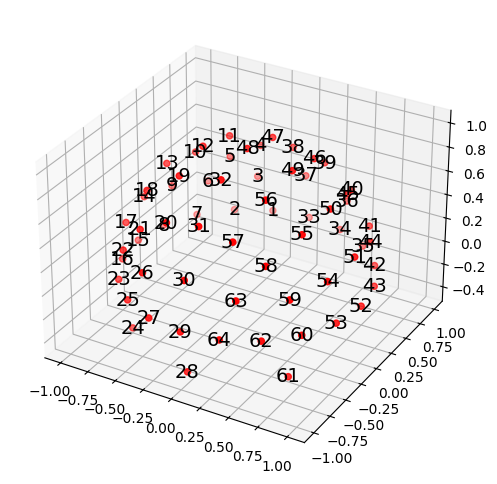

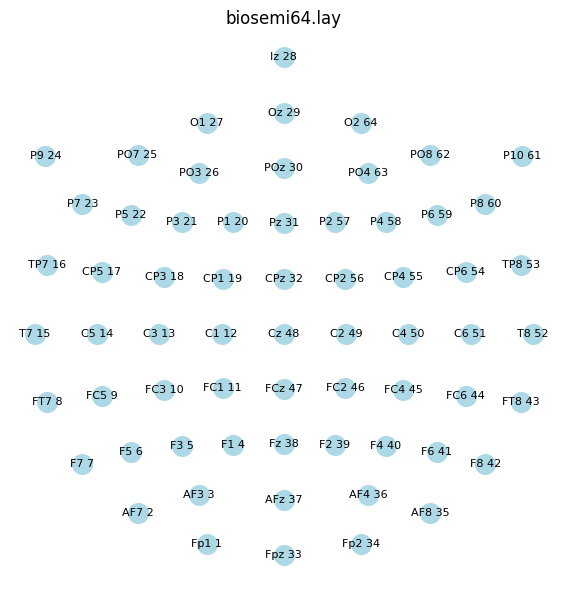

In [1]:
import pathlib
import src.layout_check

src.layout_check.plot_3D_layout(pathlib.Path("data/biosemi64.mat"))
src.layout_check.plot_biosemi_layout_to_10_20(pathlib.Path("data/biosemi64.lay"))

#### 3.1.2 Dataset import

According to the paper, three subjects were excluded from the analysis. For the reproduction, we therefore left them out too. From the original MATLAB preprocessing script, we could learn that subjects 10, 23 and 24 were excluded.

The `get_from` method of our "main" class `BidsDataset` (at least for the preprocessing) constructs a `BidsDataset` instance by reading participant metadata from the `participants.tsv` file located in the dataset's root directory. It iterates over all entries, excludes the predefined subjects, and instantiates a `Subject` object for each remaining pair of participants. The resulting list of subjects, together with the input and output paths, is then used to initialize and return the `BidsDataset` instance. The `Subject` class captures two players and the subject's events and has the functionality to preprocess the EEG data of one individual pair of players of the dataset.

In [ ]:
import pathlib
import src.dataset
import gc

dataset_path = pathlib.Path("data/ds006761")
output_dir = pathlib.Path("data/results/preprocesing")

dataset = src.dataset.BidsDataset.get_from(dataset_path, output_dir, exclude_subjects=["sub-10", "sub-23", "sub-24"])

#### 3.1.3 Import of the subjects' raw EG data and separation of the two players' raw data

Next, the `read_raw_eeg_data` method loads a subject’s raw EEG recording. Internally, it uses `mne_bids.read_raw_bids` for this. The appropriate `mne_bids.BIDSPath` is constructed based on the subject ID and task. The resulting raw object contains both players EEG data and therefore needs to be separated further, which is done by the `prepare_players` method. The `prepare_players` method separates the joint raw into two individual player raw EEG objects by selecting channel subsets corresponding to each player’s prefix. According to the MATLAB preprocessing file, there was a mixup regarding the player prefixes, which is why player 1 has prefix "2-". For each player, the method verifies the channel completeness, extracts the relevant channels, renames them to standard 10–20 system labels, assigns EEG channel types and applies a BioSemi montage for spatial electrode configuration. The method returns two MNE `Raw` objects, one for each player. Afterwards, the joint raw is immediately deleted, as it is not needed anymore consumes a considerable amount of memory.

In [5]:
sub1 = dataset.subjects[0]

raw = sub1.read_raw_eeg_data(dataset.bids_root)
raw_p1, raw_p2 = sub1.prepare_players(raw)

del raw
gc.collect()

Reading 0 ... 7514111  =      0.000 ...  3669.000 secs...


c:\Users\emmaf\Documents\Uni\repos\uni_eeg\project\src\dataset.py:397: RuntimeWarning: Did not find any channels.tsv associated with sub-01_task-RPS.

The search_str was "ds006761\sub-01\**\eeg\sub-01*channels.tsv"
  raw = mne_bids.read_raw_bids(bids_path, verbose=False)
c:\Users\emmaf\Documents\Uni\repos\uni_eeg\project\src\dataset.py:397: RuntimeWarning: Unable to map the following column(s) to to MNE:
date: 9/11/2021
player1_age: 25
player1_gender: F
player1_handedness: R
player1_pre_processing_channels_fixed: 
player2_age: 35
player2_gender: M
player2_handedness: R
player2_pre_processing_channels_fixed: T8
  raw = mne_bids.read_raw_bids(bids_path, verbose=False)


458

#### 3.1.4 Epoching

The `epoch_players` method method creates epochs from each player's raw data and uses MNE functionality internally for it. The epochs are defined based on stimulus onset sample indices, corresponding to the start of each decision phase in the rock–paper–scissors task. Consistent with the original MATLAB preprocessing pipeline, the epoch boundaries are defined via the discrete sample indices rather than directly in seconds. Each epoch spans from 0.2 seconds before stimulus onset to 5.0 seconds after stimulus onset. This allows capturing both pre-stimulus activity and the neural responses that appear as a reaction to the stimulus.

In our reproduction the explicit conversion between time in seconds and sample indices is notable. The desired epoch window is first converted into integer sample counts using the ceiling operation. The window boundaries are then converted back into seconds to comply with MNE, which only takes seconds for the epoching. With this approach we tried to ensure that the epoch boundaries closely replicate the trial definition used in the original MATLAB implementation. As a result, the same discrete data samples are selected for each epoch. As a baseline correction is applied in a later step right before the decoding and not as part of the preprocessing part (it is also like this in the paper's processing pipeline), internally, the `mne.Epochs` is called with `baseline=None`.

In [6]:
epochs_p1 = sub1.epoch_players(raw_p1)
epochs_p2 = sub1.epoch_players(raw_p2)

del raw_p1, raw_p2
gc.collect()

Not setting metadata
480 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
480 matching events found
No baseline correction applied
0 projection items activated


146

#### 3.1.5 Interpolation of the bad channels

In the original preprocessing pipeline, the interpolation of the channels identified as bad comes next. In our reproduction, this is achieved with the `interpolate` method, which performs a reconstruction of the bad channels using a custom implementation that closely replicates FieldTrip's `ft_channelrepair(method='weighted')` that is used in the MATLAB preprocessing script, as no equivalent function directly exists in MNE.

Specifically, the method identifies channels marked as bad in the respective players metadata and reconstructs their signals as weighted averages of neighboring good channels. Neighbors are defined based on spatial proximity using the BioSemi 3D electrode layout from the `biosemi64.mat` file. The weights are computed as the inverse of the Euclidean distance between electrodes to ensure that closer electrodes contribute more strongly. For each bad channel, its original signal is replaced by this weighted combination, while good channels remain unchanged.

To apply the transformation in an efficient way, the method uses `numpy` functionality to construct a full channel-by-channel repair matrix, where each row encodes how a given channel should be reconstructed. This matrix is then applied to all epochs simultaneously via matrix multiplication. If a bad channel has no valid neighboring electrodes, its data is set to `NaN`, which again matches the FieldTrip behavior (we took a look at the original implementation).

To inspect the effect of the interpolation, a bad channel and its neighbors are plotted before and after the interpolation. In the case of player 2 of subject 1, T8 was identified as a bad channel. According to the 10-20 system, among the neighboring electrodes (electrodes with close proximity) would be FT8, TP8 and C6. In the plot below, we can clearly see that compared to the other channels, the signal of T8 has a much higher variance and with more high-frequency jitter and spikes. Note, that it is a know issue in MNE that plots show up twice in Jupyter Notebooks.

Using data from preloaded Raw for 480 events and 10651 original time points ...
0 bad epochs dropped
Using matplotlib as 2D backend.
Using data from preloaded Raw for 1 events and 10651 original time points ...


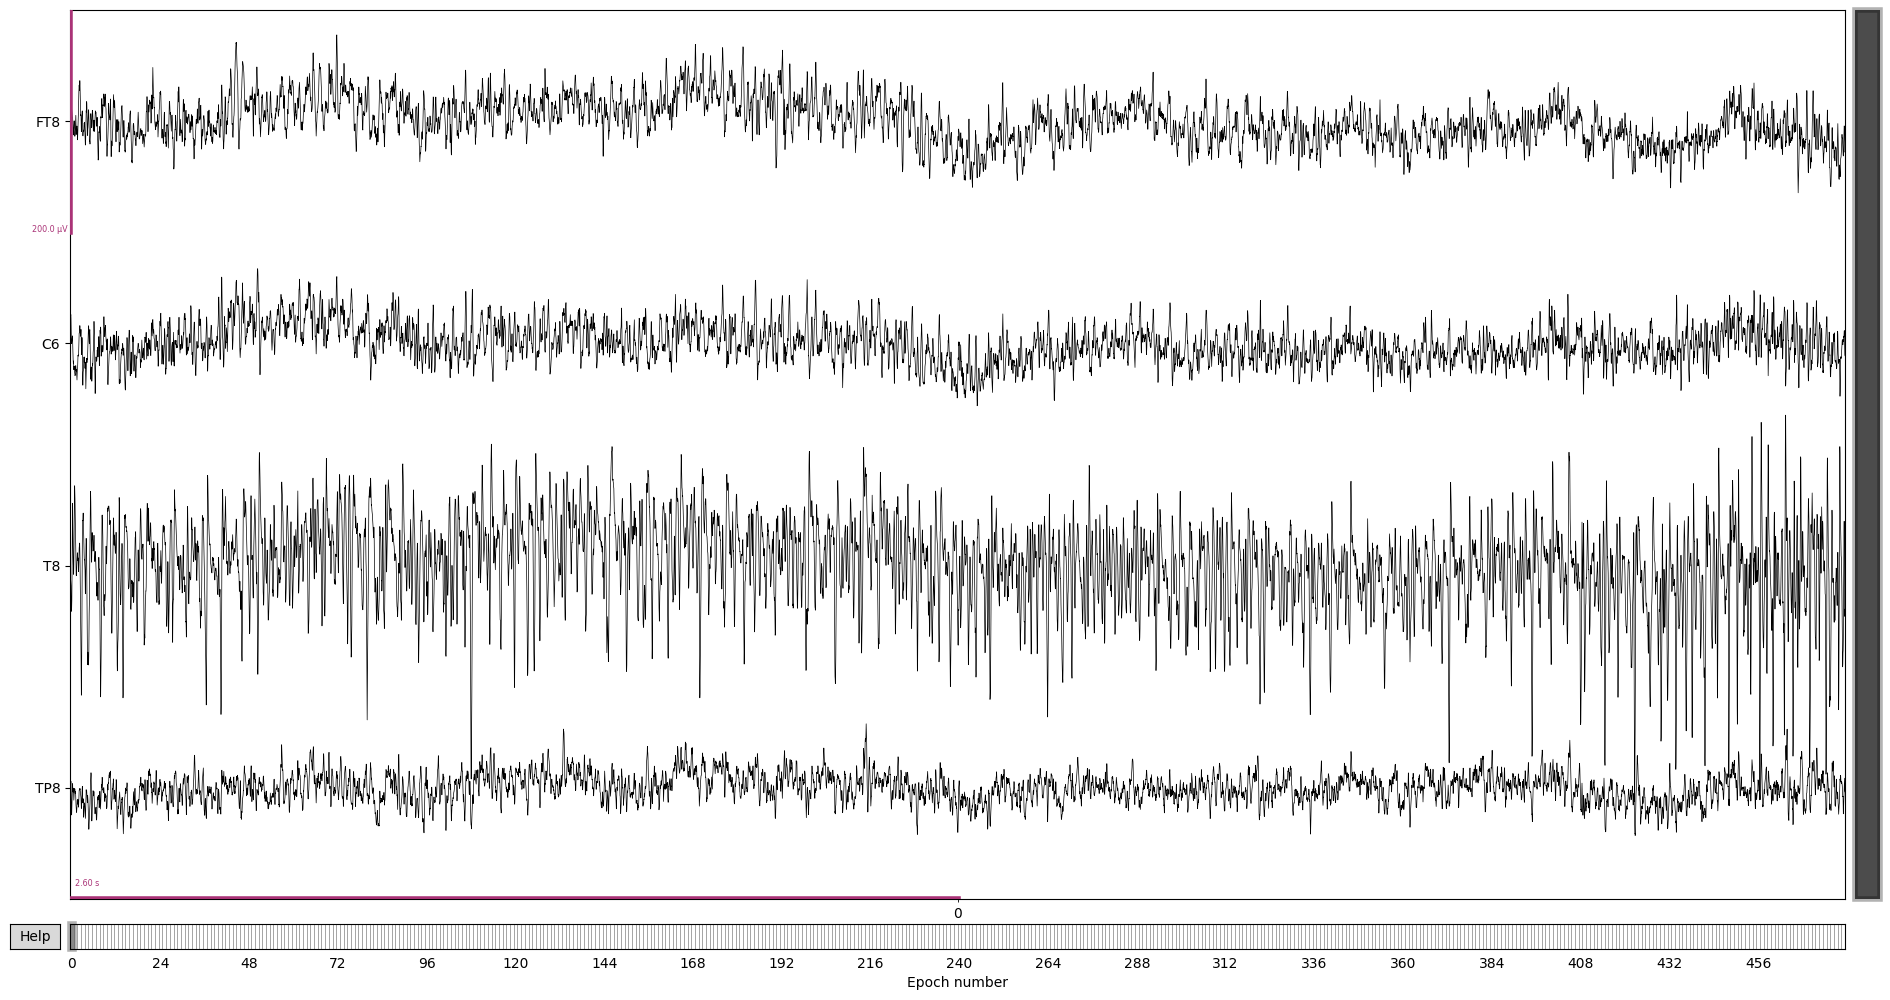

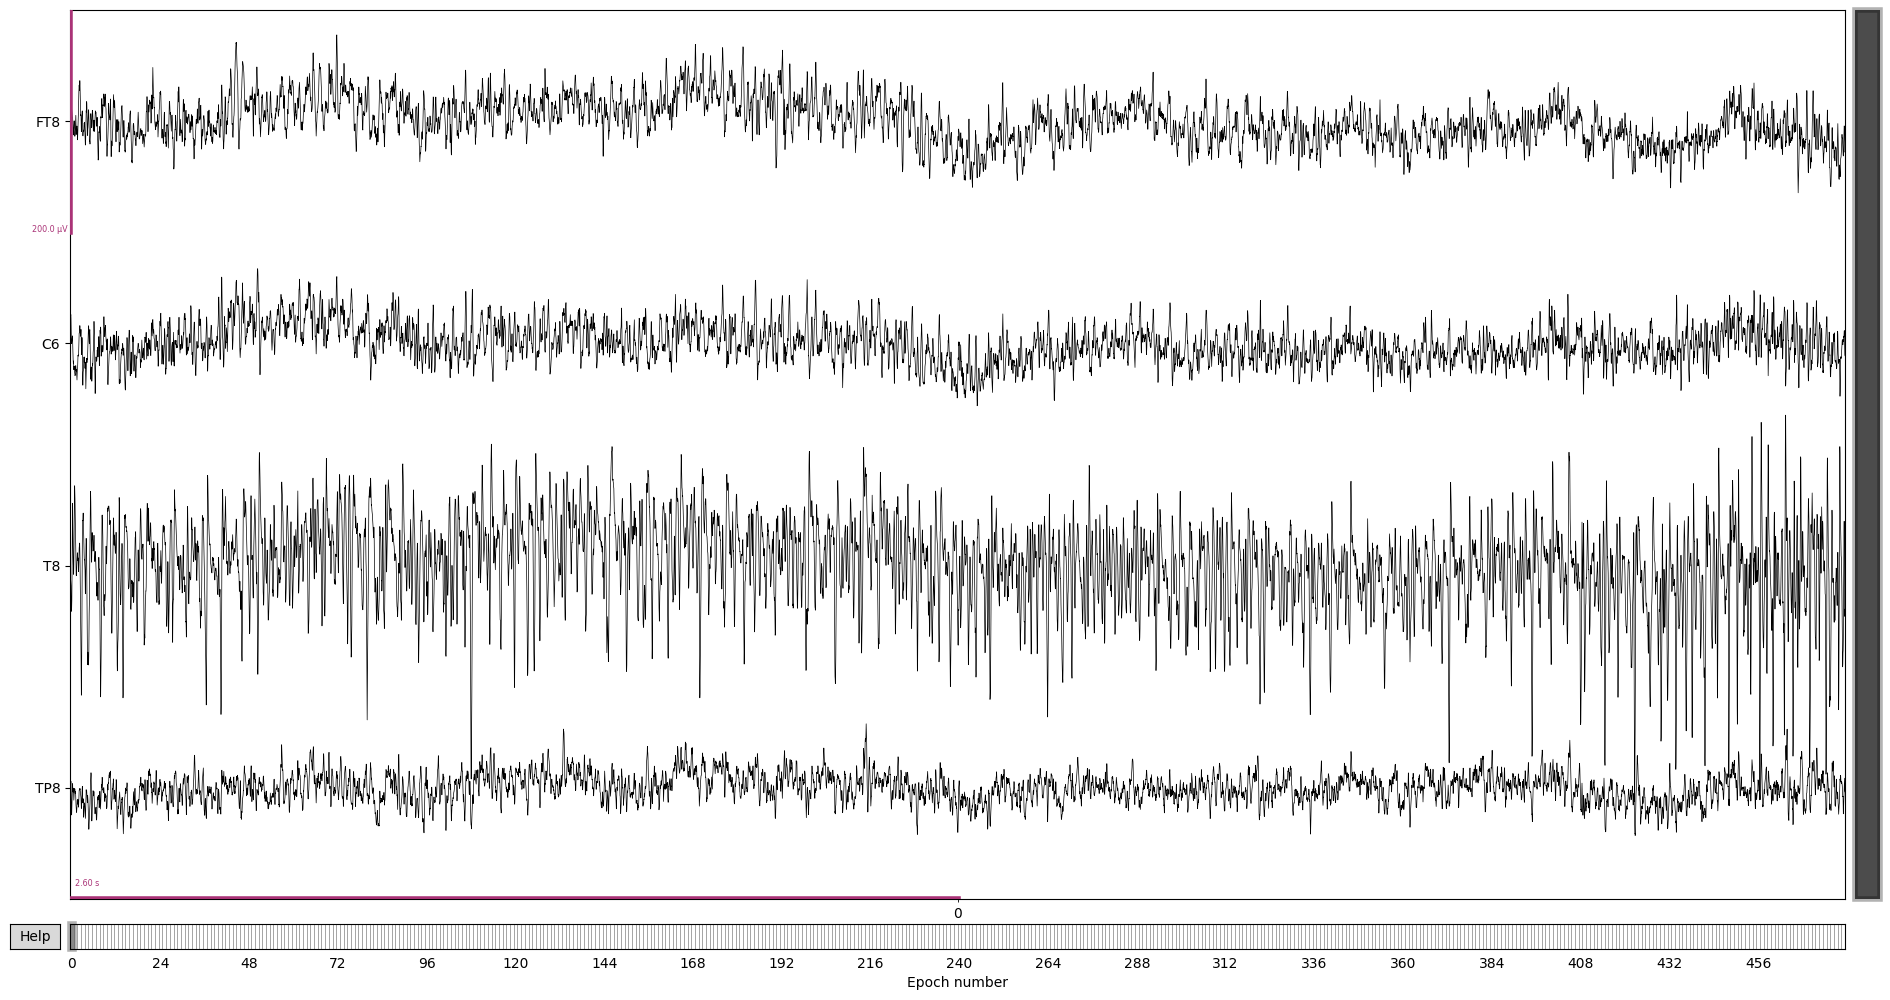

In [7]:
epochs_p2.plot(picks=["FT8", "C6", "TP8", "T8"], scalings={"eeg": 100e-6}, n_epochs=1)

Using data from preloaded Raw for 480 events and 10651 original time points ...
good neighbours of T8: ['FT8', 'FC6', 'C6', 'TP8', 'CP6']
  Player 2: Interpolated ['T8'] with FieldTrip-style weighted neighbours


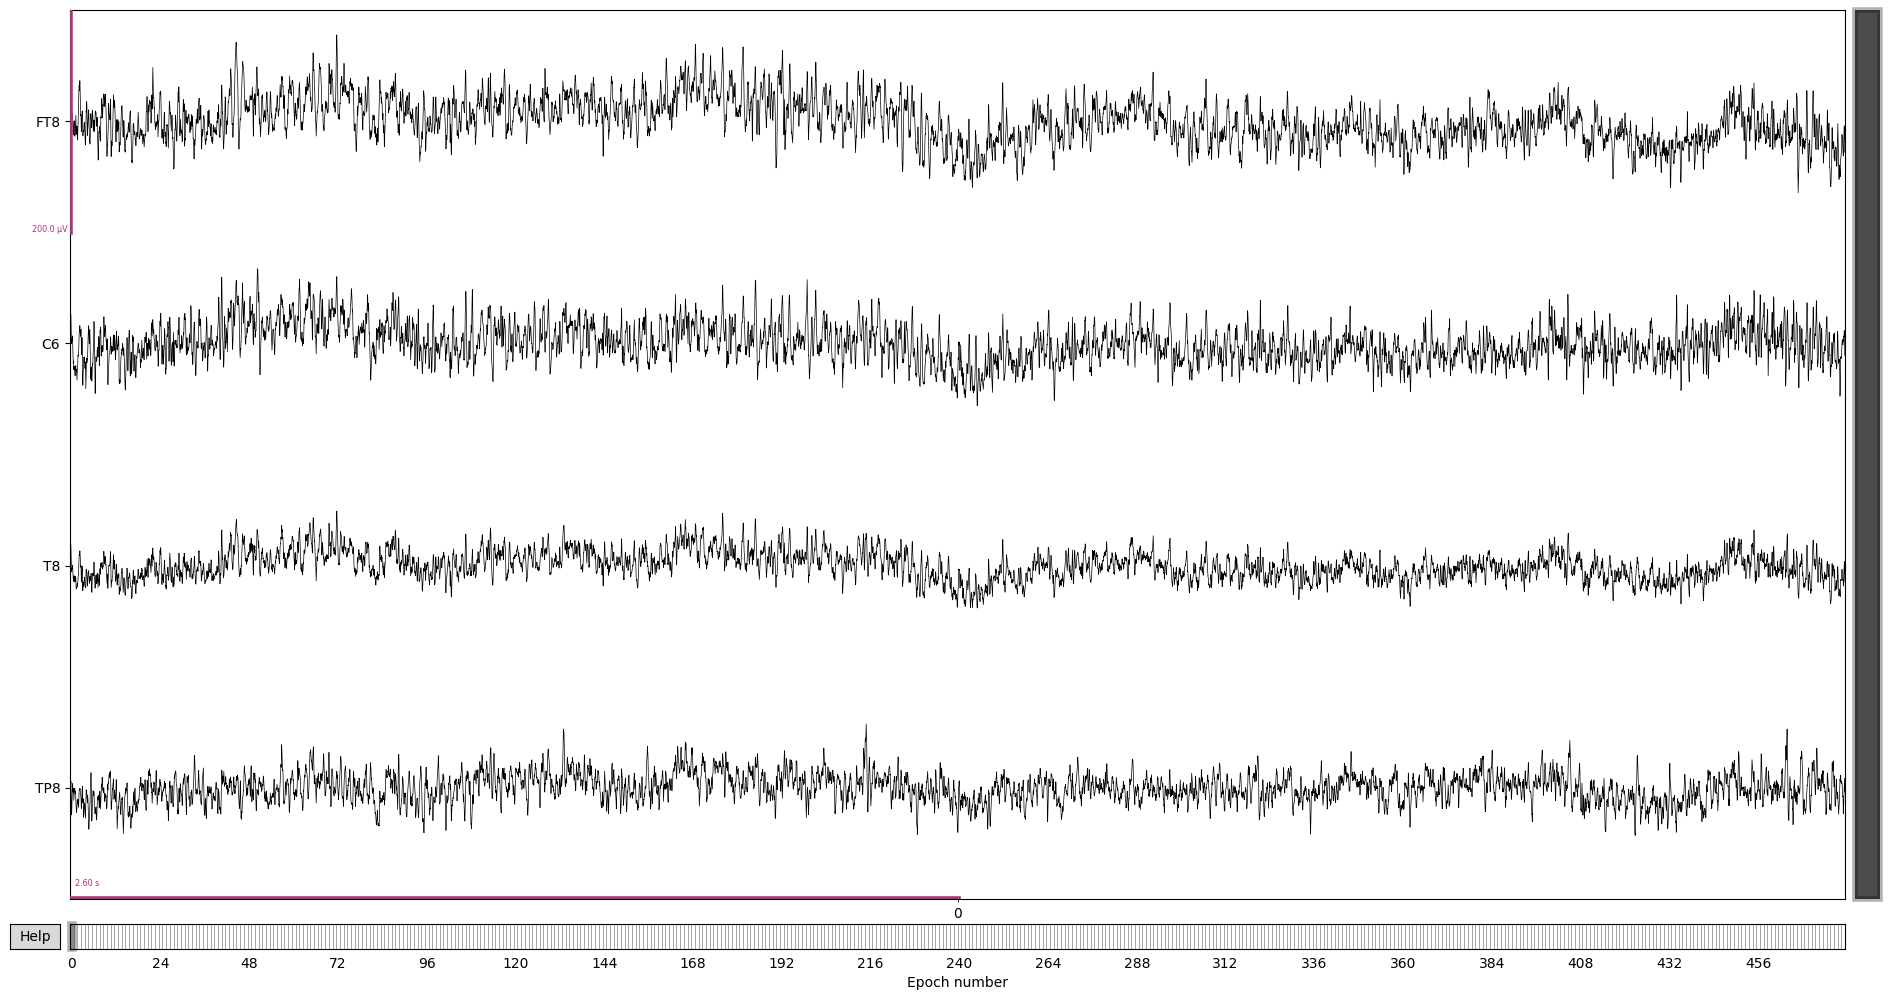

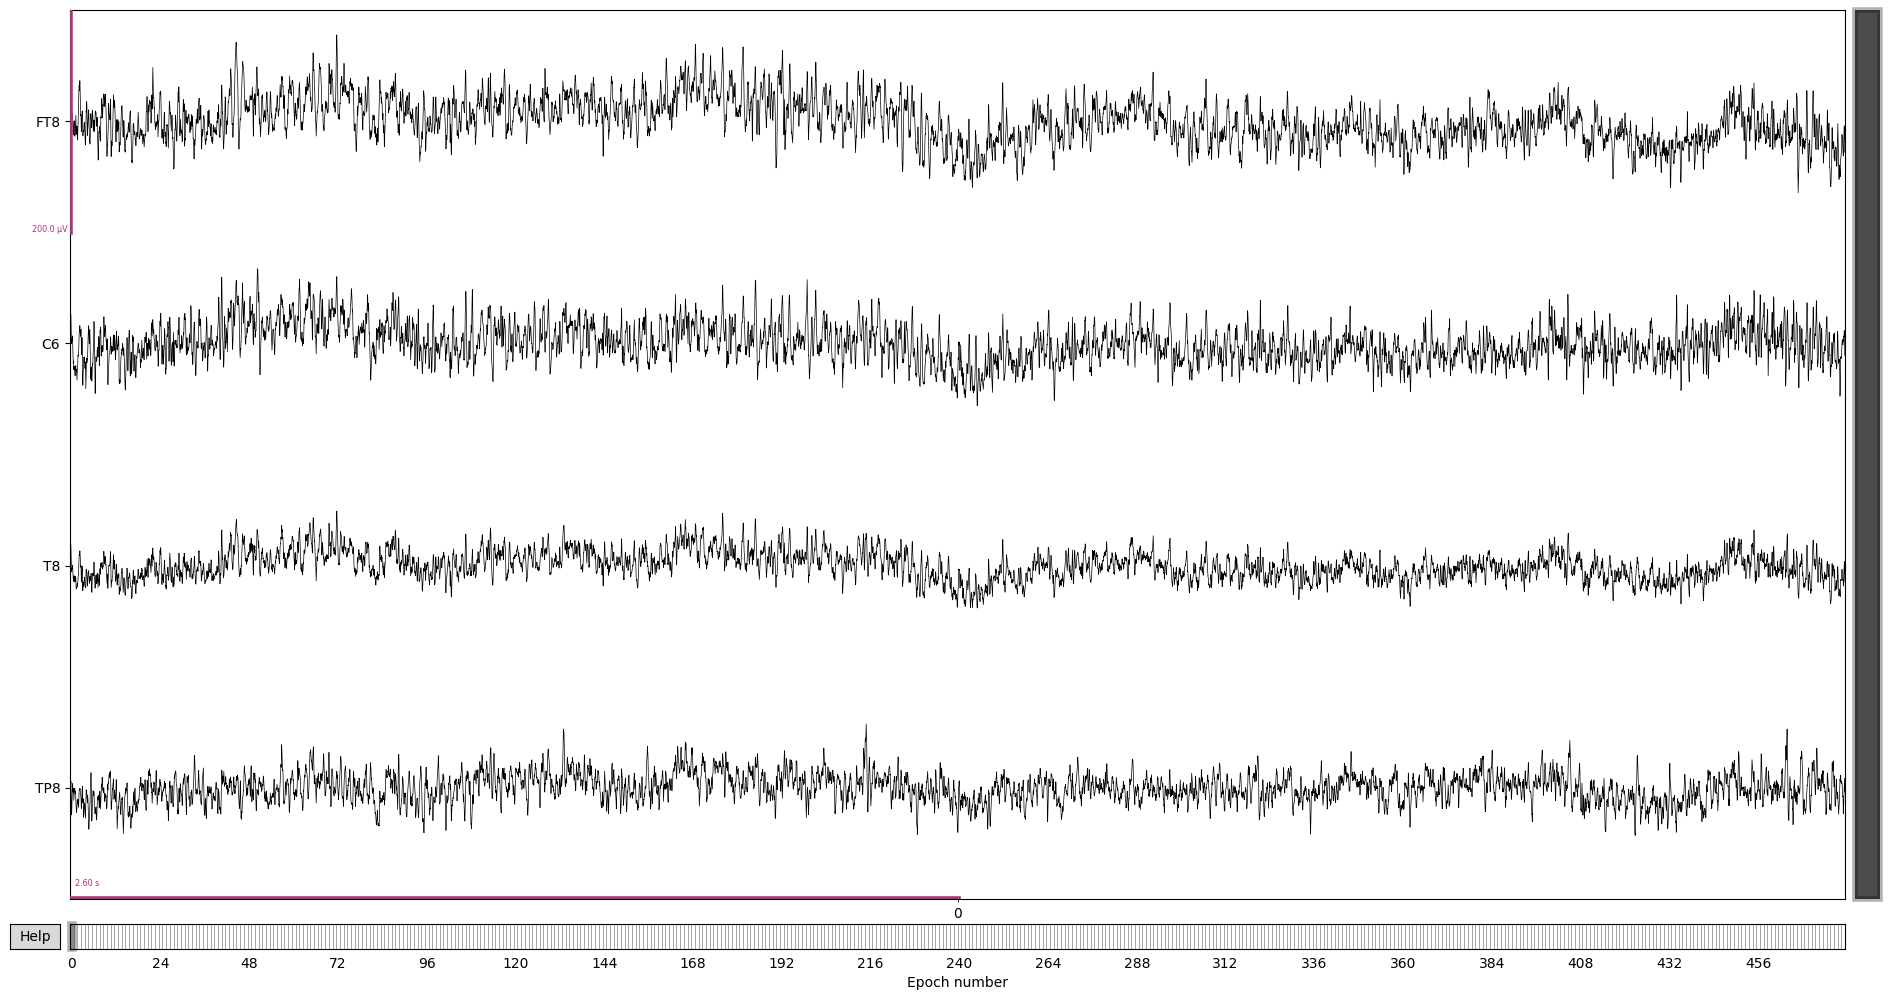

In [8]:
sub1.interpolate(epochs_p1, sub1.player1, "Player 1")
sub1.interpolate(epochs_p2, sub1.player2, "Player 2")
epochs_p2.plot(picks=["FT8", "C6", "TP8", "T8"], scalings={"eeg": 100e-6}, n_epochs=1)

After running the interpolation as decribed above, we can see that T8 appears to look a lot more like the neighboring electrodes with less jitter and spikes.

#### 3.1.6 Resampling to 256 Hz

The resampling step reduces the temporal resolution of the epoched EEG data from the original sampling rate of 2048 Hz to a lower rate of 256 Hz. From a signal-processing perspective, the EEG signals of interest are typically lower than 50 Hz (8-13 Hz alpha waves, 13-30Hz beta waves, > 30Hz Gamma waves). According to the Shannon-Nyquist theorem, a sampling rate of 256 Hz is sufficient to represent frequencies up to 128 Hz, which therefore covers the relevant bandwidth. Therefore, downsampling should not lead to a meaningful loss of information, while at the same time reduces the memory demands. According to the MNE-Bids documentation, the `resample` method additionally applies a lowpass filter at the Nyquist frequency (which is at 256 / 2 = 128 Hz in this case) to avoid aliasing effects. For a sanity check, the ERP of the F4 channel of player 1 of the first subject is visualized before and after the application of the resampling. Only one channel is visualized, because the data is not yet rereferenced and baselined.

Need more than one channel to make topography for eeg. Disabling interactivity.


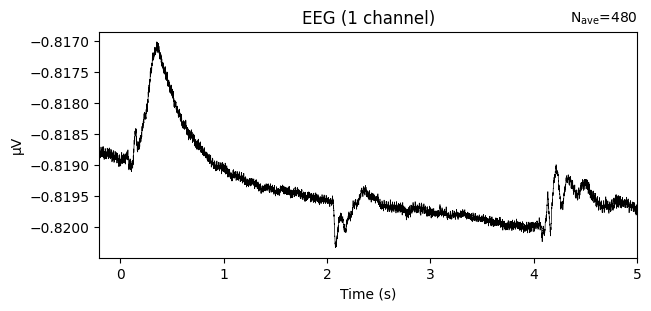

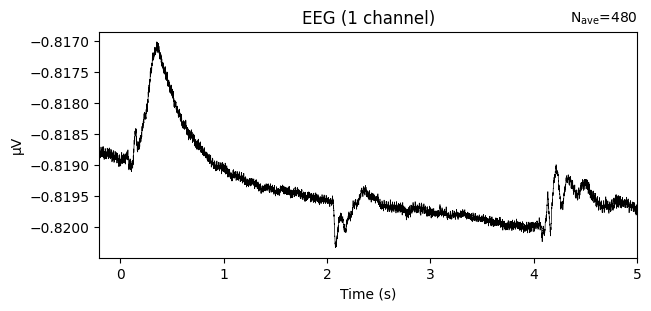

In [9]:
evoked = epochs_p1.average()
evoked.plot(picks=["F4"], scalings={"eeg": 100-6})

In [10]:
if not epochs_p1.preload:
    epochs_p1.load_data()
epochs_p1.resample(256, verbose=False)

if not epochs_p2.preload:
    epochs_p2.load_data()
epochs_p2.resample(256, verbose=False)

Using data from preloaded Raw for 480 events and 10651 original time points ...
0 bad epochs dropped


<Epochs | 480 events (all good), -0.2 – 4.995 s (baseline off), ~312.0 MiB, data loaded,
 'trial_start': 480>

Need more than one channel to make topography for eeg. Disabling interactivity.


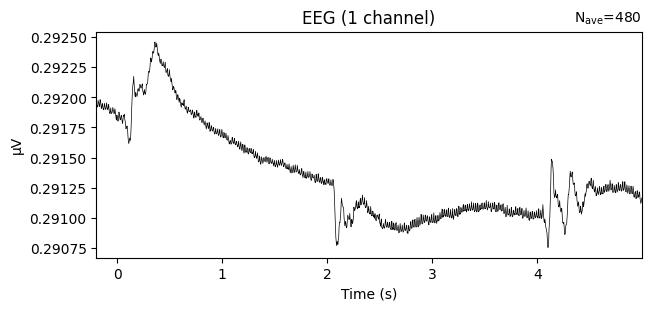

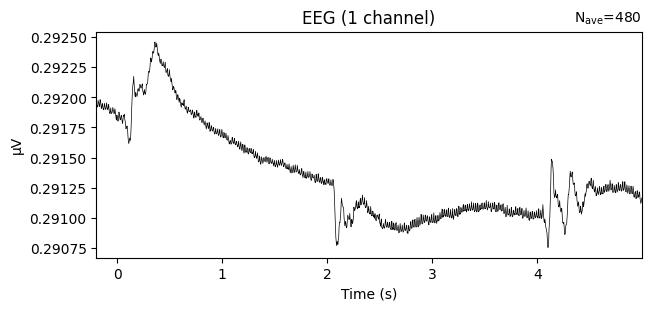

In [11]:
evoked = epochs_p1.average()
evoked.plot(picks=["Cz"], scalings={"eeg": 100-6})

As it can be seen above, the ERP of the F4 channel looks a bit smoother than before, as it would be expected after the anti-aliasing filtering that was applied as part of the downsampling. As the data is not yet rereferenced and baselined, there appears a drift and the units are still off. Still, the task related structure is visible in the signal, with peaks in the decision, response and feedback phases. This indicates that the data is not corrupted by the applied preprocessing steps.

#### 3.1.8 Save the preprocessed players' epochs

Lastly, the preprocessed EEG data is saved to disk for each player, so that it can be used in the subsequent decoding step.

In [12]:
sub1.save(epochs_p1, epochs_p2, output_dir)

del epochs_p1, epochs_p2
gc.collect()

2074

#### 3.1.9 Run the preprocessing for every subject

The preprocessing pipeline can be executed for each subject by calling the `preprocess` method of the `BidsDataset` class. Note that it is not recommended to run the preprocessing inside this Jupyter Notebook, as it takes quite some time to finish in general and using the Jupyter Kernel further slows down the process. Please use the provided `main.py` to run the preprocessing and other steps of the pipeline. 

In [ ]:
# would run the preprocessing for every subject of the dataset - prefer to run it in the main.py
dataset.preprocess()

### 3.2 Decoding Reproduction

The original decoding analysis was implemented in MATLAB using the FieldTrip (version 20240110) and CoSMoMVPA (version 1.1.0) toolboxes. Our reproduction reimplements this pipeline in Python using MNE-Python and NumPy, with custom implementations of several CoSMoMVPA functions where no direct equivalent exists in the Python ecosystem. We describe each step of the reproduction, highlighting where custom code was necessary and what discrepancies we identified along the way.

#### 3.2.1 Phase splitting and baseline correction

MNE-Python provides built-in methods for cropping epochs (`epochs.crop()`) and applying baseline correction (`epochs.apply_baseline()`). However, using these directly would not replicate the MATLAB pipeline faithfully. The MATLAB code manually selects time windows from the continuous epoch data using logical indexing on the time vector, shifts the time labels by subtracting the phase onset, and then applies baseline correction on the shifted time axis. MNE's `crop` method, by contrast, operates on the original time axis and does not support the time-shifting step that is needed before baseline correction of Parts B and C.

We therefore implemented the phase splitting and baseline correction manually using NumPy array operations. For each of the three parts (Decision, Response, Feedback), we select the relevant time window from the full epoch array, shift the time labels so that 0 corresponds to the phase onset, and subtract the mean of the –0.2 to 0 s baseline window. This approach matches the MATLAB code line-for-line: the same time boundaries (–0.2 to 2.0 s for Part A, 1.8 to 4.0 s for Part B, 3.8 to 5.0 s for Part C), the same time shifts (subtract 2.0 s for Part B, 4.0 s for Part C), and the same baseline window (–0.2 to 0 s in shifted coordinates).

#### 3.2.2 Custom LDA classifier


This was the most critical implementation decision in the entire reproduction. Scikit-learn provides `LinearDiscriminantAnalysis` with a `shrinkage` parameter, which would appear to be a straightforward replacement for CoSMoMVPA's `cosmo_classify_lda`. However, after consulting the CoSMoMVPA source code, we discovered that the two implementations use different regularisation formulas.

CoSMoMVPA computes the regularised covariance as:

$$\Sigma_{\text{reg}} = \Sigma + \lambda \cdot \frac{\text{trace}(\Sigma)}{p} \cdot I$$

where $\Sigma$ is the pooled within-class covariance normalised by $N$ (the total number of training samples), $\lambda = 0.01$ is the regularisation parameter, $p$ is the number of features, and $I$ is the identity matrix. This is an additive regularisation: the identity matrix scaled by the average eigenvalue is added to the covariance, while $\Sigma$ itself is left unchanged.

Scikit-learn's shrinkage LDA, by contrast, uses a convex combination:

$$\Sigma_{\text{reg}} = (1 - \alpha) \cdot \Sigma + \alpha \cdot \frac{\text{trace}(\Sigma)}{p} \cdot I$$

where $\alpha$ is the shrinkage intensity. Both toolboxes normalise the pooled within-class covariance by $N$ (the total number of training samples), so the covariance estimates themselves are identical. The difference lies solely in how the regularisation is applied: CoSMoMVPA adds a scaled identity to the full covariance, while scikit-learn interpolates between the covariance and a scaled identity. With $\lambda = \alpha = 0.01$, the additive formula gives $\Sigma + 0.01 \cdot \mu \cdot I$ while the convex formula gives $0.99 \cdot \Sigma + 0.01 \cdot \mu \cdot I$ (where $\mu = \text{trace}(\Sigma)/p$). The practical effect is that scikit-learn slightly down-weights the off-diagonal covariance structure as $\alpha$ increases, whereas CoSMoMVPA preserves it entirely and only inflates the diagonal. At $\lambda = 0.01$ this difference is small, but it is nonzero and accumulates across the 49,600+ classifier fits in the full analysis.

We therefore wrote a custom LDA implementation that matches the CoSMoMVPA source code exactly:

1. Compute per-class means
2. Compute pooled within-class scatter matrix: $S_w = \sum_k (X_k - \mu_k)^T (X_k - \mu_k)$
3. Normalise by $N$ (total training samples): $\Sigma = S_w / N$
4. Add regularisation: $\Sigma_{\text{reg}} = \Sigma + 0.01 \cdot \frac{\text{trace}(\Sigma)}{p} \cdot I$
5. Compute class weights: $W = \mu \cdot \Sigma_{\text{reg}}^{-1}$
6. Compute bias: $b_k = \sum_j W_{kj} \cdot \mu_{kj}$
7. Predict: $\hat{y} = \arg\max_k \left( x \cdot W_k^T - 0.5 \cdot b_k \right)$

#### 3.2.3 Custom `cosmo_sample_unique` for balanced pseudo-trial averaging


CoSMoMVPA's `cosmo_average_samples` function internally calls `cosmo_sample_unique` to generate balanced sampling indices. This function ensures that across all 20 repeats, each original trial is used approximately the same number of times, unlike simple random sampling, where some trials might be used many times while others are never selected.

The algorithm works by:

1. Generating (`repeats` + 1) random permutations of the trial indices and concatenating them column-wise into a flat vector
2. Walking through this vector with a position pointer to fill each repeat column with `count` values, skipping any position that has already been consumed globally or whose value already appears in the current column (preventing within-column duplicates)
3. Sorting each column of the resulting index matrix

The extra permutation (repeats + 1 rather than repeats) provides overflow buffer so the walk does not run out of candidates. We ported this algorithm directly from the CoSMoMVPA MATLAB source code to Python, including the column-major flattening (`ravel(order='F')`) to match MATLAB's memory layout. A simpler approach, such as calling `rng.choice(indices, size=count, replace=False)` independently for each repeat, would not guarantee balanced usage across repeats and would produce different pseudo-trials.

#### 3.2.4 Channel searchlight

For the channel searchlight, the original MATLAB code uses `cosmo_meeg_chan_neighborhood(ds, 'count', 4)` to define a neighbourhood of exactly 4 nearest channels for each searchlight centre. We replicate this by computing a pairwise Euclidean distance matrix from the electrode positions (obtained from the MNE montage), then for each channel selecting the 4 channels with the smallest distances. Combined with the centre channel itself, this gives 5 features per searchlight location, matching the original.

One subtlety here is the coordinate space. Since we select neighbours by rank order (the 4 closest) rather than by a distance threshold, the absolute scale of the coordinates does not affect the neighbour selection, the ranking is preserved under any uniform scaling. In practice, this leads to similar results as the original MATLAB code, where the neighbourhood distance threshold was 0.99 while all the coordinates were within a unit circle. In other words, there would always be more than 4 neighbours close enough to be considered. 

### 3.3 Markov Analysis and Statistics Reproduction

The behavioural responses used for the Markov analysis are stored in `.tsv` files for each participant pair. Each row corresponds to a single trial in the experiment and contains timing information, the responses of both players, their reaction times, and the outcome of the round.

A simplified example from the original data structure is shown below:

| onset | duration | onset_sample | trial_num | player1_resp | player1_rt | player2_resp | player2_rt | outcome |
|------|--------|-------------|---------|-------------|-----------|-------------|-----------|-------|
| 420.78 | 5 | 861754 | 1 | 2 | 0.025 | 1 | 1.308 | 2 |
| 425.77 | 5 | 871977 | 2 | 3 | 1.51 | 1 | 1.11 | 3 |

The columns relevant for the Markov analysis are the response columns:

- player1_resp – response of player 1  
- player2_resp – response of player 2  

Responses are encoded numerically:

- 1 = Rock
- 2 = Paper
- 3 = Scissors
- 0 = No response

For each pair of participants, 480 trials were recorded and extracted from the `.tsv` files in order to be processed as input for the Markov chain algorithm.

#### 3.3.1 First-Order Markov Chain Model

The behavioural predictability analysis is based on a first-order Markov chain, a probabilistic model commonly used to describe sequential processes in which the probability of the next state depends only on the current state.

Formally, the Markov property states that the future probability of a random variable in a Markov chain is conditionally independent of all earlier states (probabilities), given the present state. In mathematical terms:

$$
P(X_{t+1} \mid X_t, X_{t-1}, ..., X_1) = P(X_{t+1} \mid X_t)
$$

where   
- $X_t$ denotes the response at trial $t$  
- $X_{t+1}$ denotes the response at the next trial  

This property implies that the model does not consider the entire history of responses, but only the most recent one when predicting the next action.

##### Transition Counts

The first step of the algorithm implementation constructs cumulative counts of response transitions across trials. These counts are stored in a matrix called `prob_data`.

Each row corresponds to a trial and contains cumulative counts of transitions observed up to that trial. The matrix has the following structure:

| Column | Meaning |
|--------|--------|
| 1      | # Rock |
| 2–4    | Rock → (R, P, S) |
| 5      | # Paper |
| 6–8    | Paper → (R, P, S) |
| 9      | # Scissors |
| 10–12  | Scissors → (R, P, S) |

The following code snippet illustrates the iterative update process of the matrix:

In [ ]:
# Illustrative code
if prev_resp == 1:  # Rock
    prob_data[i, 1] += 1
    prob_data[i, 2 + (curr_resp - 1)] += 1

elif prev_resp == 2:  # Paper
    prob_data[i, 5] += 1
    prob_data[i, 6 + (curr_resp - 1)] += 1

elif prev_resp == 3:  # Scissors
    prob_data[i, 9] += 1
    prob_data[i, 10 + (curr_resp - 1)] += 1

During each iteration, the counts from the previous trial are copied and
updated according to the current transition.

If the previous response was Rock, Paper, or Scissors, the corresponding
transition counts are incremented.

##### Sliding Window & Prediction

Rather than computing transition probabilities from the entire response
history, the algorithm used in the paper estimates them using a sliding window of
recent trials.

Window sizes between 5 and 100 trials are tested. These are also included in the main plots in the paper. For each trial
$i$, the transition counts inside the window are computed by subtracting
cumulative counts:

$$
\text{counts}_w = \text{prob\_data}[i - 1] - \text{prob\_data}[i - w]
$$

If the current trial occurs earlier in the experiment and a full window is
not yet available, all transitions observed up to that particular trial are used instead.

In [ ]:
# Illustrative code
if i < window_size + 1:
    inter = prob_data[i - 1, :]
else:
    inter = prob_data[i - 1, :] - prob_data[i - window_size, :]

**Transition Probabilities**

The model describes behaviour using transition probabilities, i.e., the probability of playing a move given the previous move:

- $P(P|R)$: probability of playing Paper after Rock  
- $P(S|P)$: probability of playing Scissors after Paper  
- $P(R|S)$: probability of playing Rock after Scissors  

These are estimated empirically using:

$$
P(j \mid i) = \frac{\text{count}(i \rightarrow j)}{\text{count}(i)}
$$

If there is insufficient data, probabilities default to uniform (1/3). This corresponds to a maximum likelihood estimate (MLE) based on observed transitions.

**Transition Matrix**

All transition probabilities are stored in a 3×3 transition matrix:

$$
T =
\begin{bmatrix}
P(R|R) & P(P|R) & P(S|R) \\
P(R|P) & P(P|P) & P(S|P) \\
P(R|S) & P(P|S) & P(S|S)
\end{bmatrix}
$$

- Rows = previous response  
- Columns = next response  

If behaviour is random, all probabilities would approach 1/3.

##### Prediction Rule and Accuracy Computation

Once the transition probabilities are estimated, the model generates
trial-by-trial predictions of the participant’s next response.

For each trial $i$, the algorithm:

1. Identifies the most recent valid response $ X_t $
2. Retrieves the corresponding row of the transition matrix
3. Selects the most likely next response using:

$$
\hat{X}_{t+1} = \operatorname*{argmax}_{x \in \{R,P,S\}} P(x \mid X_t)
$$

In [ ]:
# Illustrative code
last_resp = responses[idx - 1] - 1
probs = m_prob[last_resp]

pred_move = np.argmax(probs)
prob_res[i, 1] = pred_move + 1
prob_res[i, 2] = probs[pred_move]

The predicted response is the one with the highest probability,
which is obtained using an `argmax` function.

**Accuracy Measure**

Prediction performance is evaluated using the classification accuracy, which is also the main metric captured in the Figure 1f:

$$
\text{Accuracy} = \frac{\text{Number of correct predictions}}{\text{Total number of predictions}}
$$

####  3.3.2 Statistical Plots

##### Group-Level Analysis (Paper Figure 1f)

To evaluate whether behavioural predictability is consistent across participants, in the paper a group-level analysis was performed and reproduced by us by aggregating prediction accuracies across all subjects and window sizes. This allowed us to determine whether the observed predictability is a robust phenomenon rather than an individual-specific effect.

**Data Aggregation**

For each participant (including both players in each pair), the Markov analysis produces a vector of prediction accuracies:

$$
\text{accuracy} \in \mathbb{R}^{|W|}
$$

where $$ W = \{5, 6, ..., 100\} $$ denotes the set of sliding window sizes.

All participants are combined into a matrix:

$$
A \in \mathbb{R}^{N \times |W|}
$$

where:

* $N$ = total number of participants (both players pooled)  
* $|W|$ = number of window sizes  

Each row corresponds to one participant, and each column corresponds to a specific window size.

In [ ]:
# Illustrative code
group_mean = np.mean(all_participants, axis=0)
group_sem = np.std(all_participants, axis=0) / np.sqrt(len(all_participants))

The group-level Markov analysis confirms that participants exhibit systematic and predictable behaviour that deviates from the optimal random play strategy. This could be observed in the paper graph but also in our same reproduction from the code. This reproduces the key behavioural finding of the original paper, showing that human decisions in such competitive settings like playing a Rock, Paper, Scissors game become structured rather than random. Our reproduced plot is shown below:

<img src="images/Markov_chain_prediction_accuracy.png" width="400"> 

##### Behavioural Analyses (Paper Figures 1c–e)

To complement the Markov predictability analysis as in the original paper, we reproduced the key behavioural statistics and plots reported in the original paper. These analyses provide insight into how participants actually behave during the game and whether their choices align with random or strategic play.

**Game Outcome Distribution (Fig. 1c)**

We first quantified the distribution of game outcomes across all trials for each participant. Specifically, we computed:

- Percentage of wins (for the overall winner)  
- Percentage of losses (for the overall winner)  
- Percentage of draws  

In [ ]:
# Illustrative code
percent_won, percent_lost, percent_drawn = subject.get_winners_outcome_distribution()

This analysis serves as a sanity check to ensure that the game dynamics are balanced. In an ideal random setting as we previously mentioned, one would expect approximately equal proportions of wins, losses, and draws (each close to 33.3%). Some deviations from this distribution may indicate strategic imbalances or behavioural biases. Our reproduced plot:

<img src="images/1c.png" width="400"> 

**Response Bias (Fig. 1d)**

Next, we examined whether participants exhibited preferences for specific responses (e.g., Rock, Paper, or Scissors). For each participant, we ranked as in the paper responses by frequency and extracted:


- Most frequently played response  
- Moderately played response  
- Least frequently played response  

This allows us to assess whether participants follow a uniform random strategy or show systematic biases.

*Observation:* 
Participants consistently favoured certain responses, most notably *Rock*, indicating a clear deviation from uniform randomness. Instead of selecting each option with equal probability (1/3), participants displayed skewed choice distributions.

This bias suggests:

- Habit formation or default strategies, for example that *Rock* is most frequently chosen or Scissors is least frequently chosen  
- Cognitive shortcuts in decision-making  
- Potential exploitability by adaptive opponents  


<img src="images/1d.png" width="400"> 

**Response Switching (Fig. 1e)**

Figure 1e examines how participants adjusted their behaviour based on previous outcomes. Specifically, we computed the probability of switching to a different response after:

- A win  
- A loss  
- A draw  

$$
\text{Change} = (X_t \neq X_{t-1})
$$

The expected probability of switching under randomness is $ \approx 66.7 \% $

Results showed that participants tend to **switch responses more
often than expected**, consistent with heuristic strategies such as:

- win–stay / lose–shift  
- cyclic patterns  

Our reproduced plot: 

<img src="images/1e.png" width="400">

## 4. Our Contributions

### 4.1 Preprocessing

Preprocessing is often assumed to improve decoding performance by enhancing the signal quality. However, as highlighted in the paper ["How EEG preprocessing shapes decoding performance"](https://www.nature.com/articles/s42003-025-08464-3), it is not necessarily a silver bullet in decoding analysis. In particular, the paper demonstrates that certain preprocessing steps can remove not only noise but also information that is predictive for the classifier, since artifacts themselves may systematically covary with the experimental conditions. For example, in the context of the rock–paper–scissors task, it would be plausible that muscle activity or eye blinks occur more frequently after a player has lost, which would introduce artifacts that a classifier could exploit. Consequently, aggressive artifact removal may reduce decoding performance by eliminating these non-neural signals. The paper therefore proposes a cautious approach for preprocessing and suggests that relatively simple steps such as filtering and detrending can be beneficial, while more complex artifact correction procedures should be evaluated carefully in terms of their impact on decoding. By taking these considerations into account, we tried to explore different preprocessing strategies: band-pass filtering using a relatively high high-pass and low low-pass cutoff, as well as a combination of filtering and detrending, which produced the best results in the paper, and evaluation of artifact handling by comparing interpolation of channels marked as bad with the alternative of simply dropping those channels. The effects of the described additional preprocessing steps will again be shown for one player in this Notebook. To run the preprocessing for all of the subjects, please use the functionality provided in the `main.py`

#### 4.1.1 Application of a bandpass filter

We first applied a band-pass filter to the continuous, raw EEG data of each player using a high-pass cutoff of 1 Hz and a low-pass cutoff of 35 Hz. This frequency range was chosen because this interval contains the frequencies of interest for cognitive EEG, including alpha activity (approximately 8–13 Hz), as well as theta (4–7 Hz) and beta (13–30 Hz) bands, while  the effects of very slow drifts and high-frequency noise such as muscle activity are weakened. We performed the filtering on the continuous raw data rather than on the epoched data. This choice is important because filtering assumes temporal continuity. Applying it to already segmented epochs introduces artificial boundaries that can lead to edge artifacts and distortions near the beginning and end of each trial. By filtering the raw signal before epoching the data, these boundary effects are minimized, which should result in a more stable signal representation.

For the filtering, we used the MNE function `filter`, which by default uses a FIR filter.

In [14]:
# Get sub1's raw data again
sub1 = dataset.subjects[0]

raw = sub1.read_raw_eeg_data(dataset.bids_root)
raw_p1, raw_p2 = sub1.prepare_players(raw)

del raw
gc.collect()

Reading 0 ... 7514111  =      0.000 ...  3669.000 secs...


c:\Users\emmaf\Documents\Uni\repos\uni_eeg\project\src\dataset.py:397: RuntimeWarning: Did not find any channels.tsv associated with sub-01_task-RPS.

The search_str was "ds006761\sub-01\**\eeg\sub-01*channels.tsv"
  raw = mne_bids.read_raw_bids(bids_path, verbose=False)
c:\Users\emmaf\Documents\Uni\repos\uni_eeg\project\src\dataset.py:397: RuntimeWarning: Unable to map the following column(s) to to MNE:
date: 9/11/2021
player1_age: 25
player1_gender: F
player1_handedness: R
player1_pre_processing_channels_fixed: 
player2_age: 35
player2_gender: M
player2_handedness: R
player2_pre_processing_channels_fixed: T8
  raw = mne_bids.read_raw_bids(bids_path, verbose=False)


1398

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 6759 samples (3.300 s)

Effective window size : 1.000 (s)
Effective window size : 1.000 (s)
before:
Plotting power spectral density (dB=True).


c:\Users\emmaf\Documents\Uni\repos\uni_eeg\project\.venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


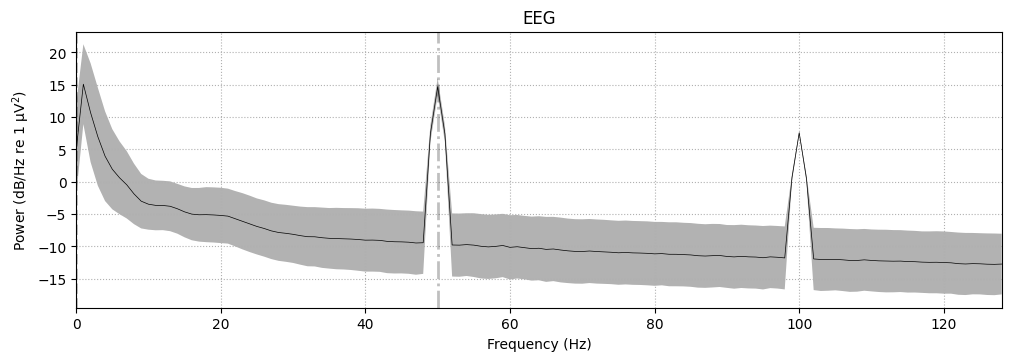

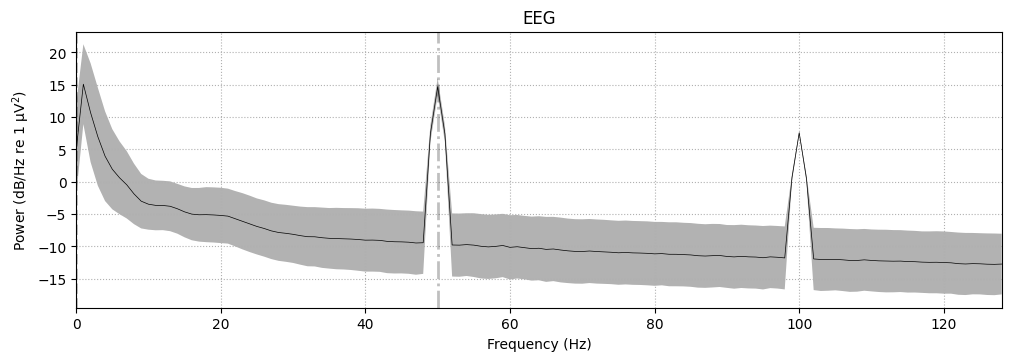

In [15]:
# apply the filtering
raw_p1_filtered = raw_p1.copy().filter(l_freq=1.0, h_freq=35.0)

psd_before = raw_p1.compute_psd(fmax=128)
psd_after = raw_p1_filtered.compute_psd(fmax=128)

print("before:")
psd_before.plot(average=True)

after:
Plotting power spectral density (dB=True).


c:\Users\emmaf\Documents\Uni\repos\uni_eeg\project\.venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


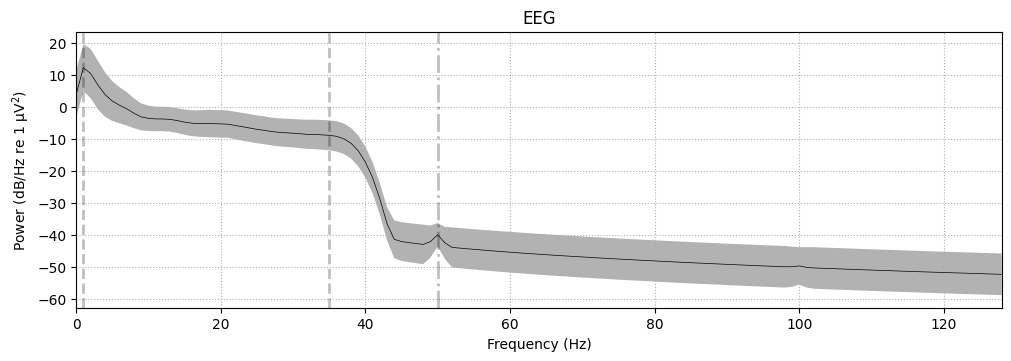

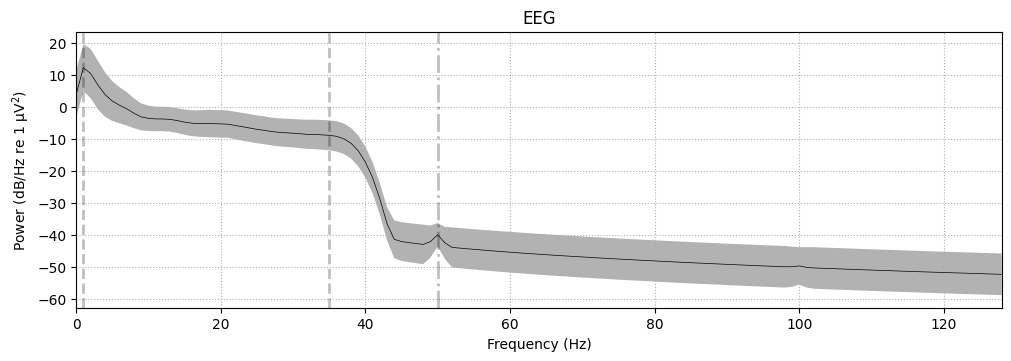

In [16]:
print("after:")
psd_after.plot(average=True)

The power spectral density graph of the unfiltered raw of player 1 shows a spike at 50 Hz and a spike at 100 Hz, which is a harmonic of 50 Hz. According to the MNE tutorial on artifact detection, this is characteristic for powerline interference. After applying the band-pass filter, those peaks are considerably weakened, as the frequencies above the upper cutoff are suppressed.

#### 4.1.2 Decoding results of preprocessing with filtering

A comparison of decoding performance with (left figure) and without (default pipeline from the paper, right figure) band-pass  filtering (1–35 Hz) reveals that filtering partially led to a slight increase in the decoding accuracy, especially during the feedback phase of the opponent's response plot, while the overall temporal structure of the results remained unchanged. However, improvements were not consistent across all conditions. In some cases, the decoding performance was comparable or even slightly reduced after filtering, for example during the response phase of the opponent’s previous response condition (plot (d)). The peak decoding times and condition-specific patterns are consistent across both preprocessing approaches, which shows that the observed effects are not introduced by filtering artifacts. These findings support the notion that while band-pass filtering can enhance decoding performance, it does not fundamentally alter the underlying decodable information, which appears to be robustly present in the data even without such preprocessing.

<img src="images/group_lda_cosmo_bandpass_1_35.png" width="400"> <img src="images/group_lda_cosmo.png" width="400">

#### 4.1.4 Filtering and linear detrending 

In addition to band-pass filtering, linear detrending was applied to investigate whether further removal of slow signal drifts would improve decoding performance. Similar to the filtering, linear detrending aims to stabilize the signal by reducing low-frequency jitter, and the paper ["How EEG preprocessing shapes decoding performance"](https://www.nature.com/articles/s42003-025-08464-3) suggests that their effects can be complementary in some decoding settings. Therefore, we evaluated their combined use to assess whether detrending comes with additional improvements beyond filtering alone. To visually inspect the effect of linear detrending, the first twenty epochs of player 1 are plotted, once without the detrending applied, and once with. For the detrending, we used the MNE functionality `mne.Epochs` with the argument `detrend` set to 1, which is - as mentioned before - called inside the `Subject.epoch_players` method.

Not setting metadata
480 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
480 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 480 events and 10651 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 20 events and 10651 original time points ...


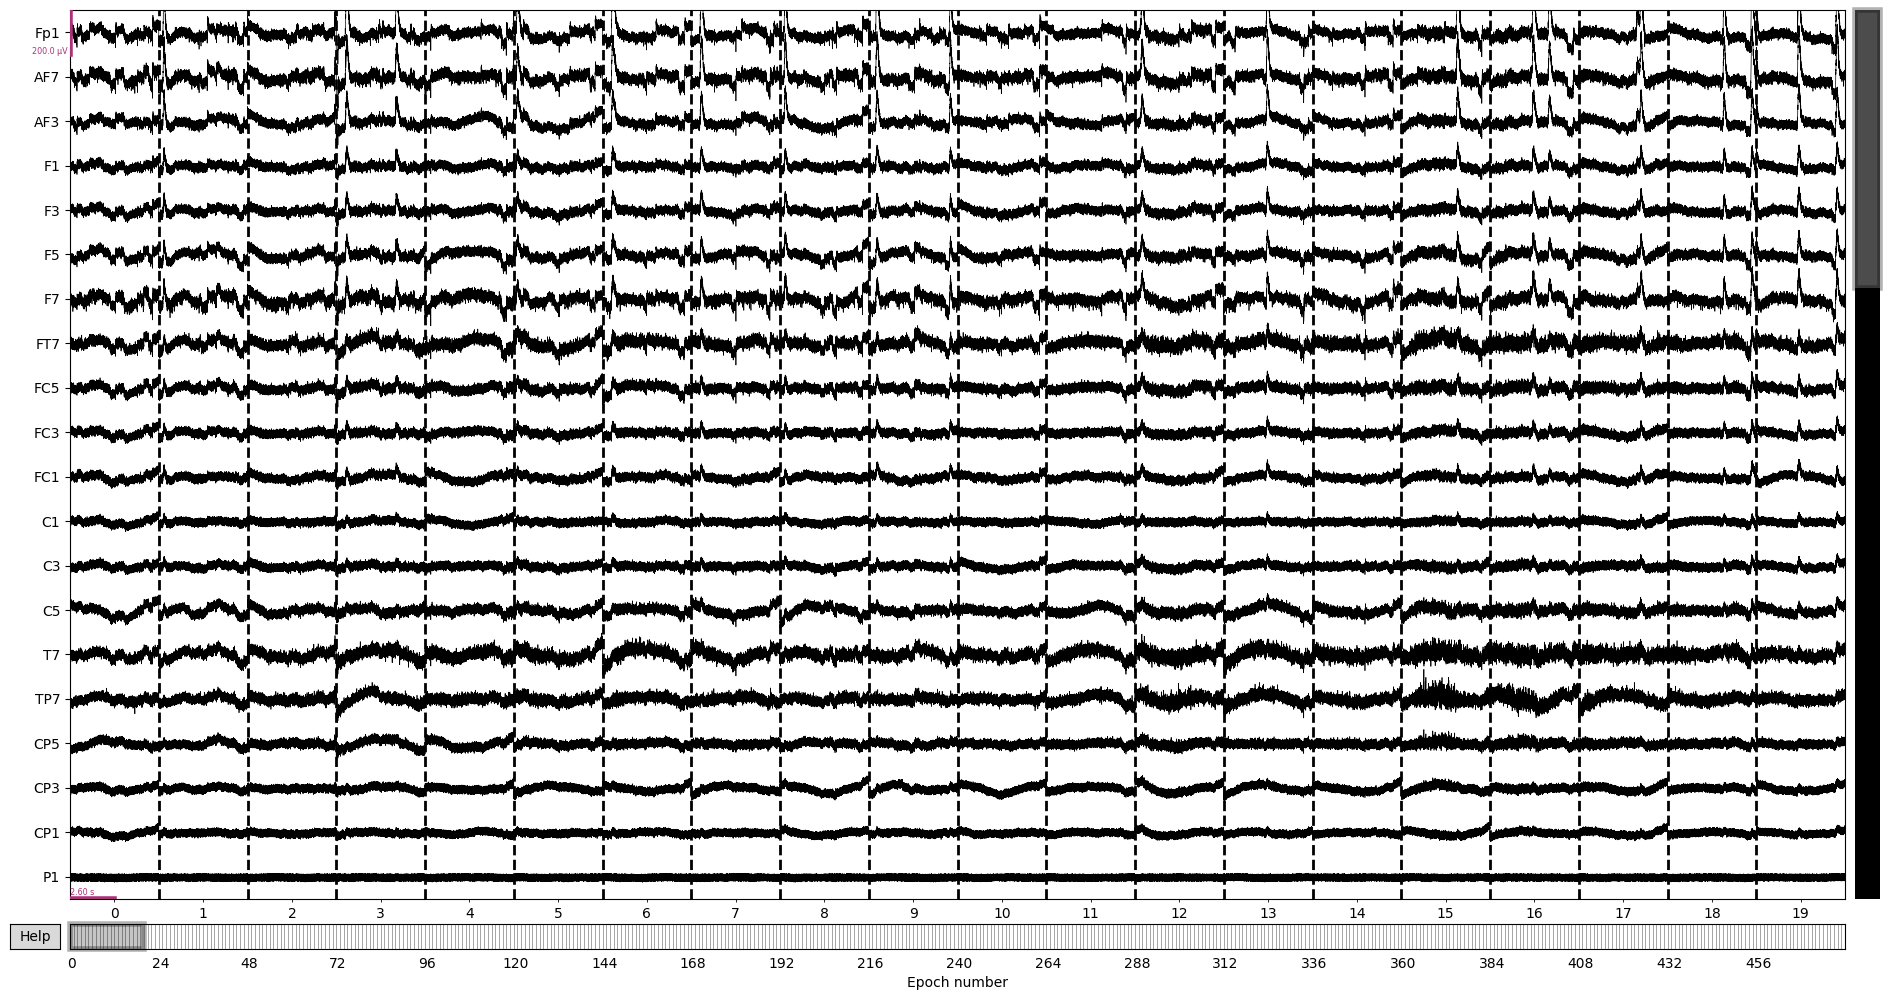

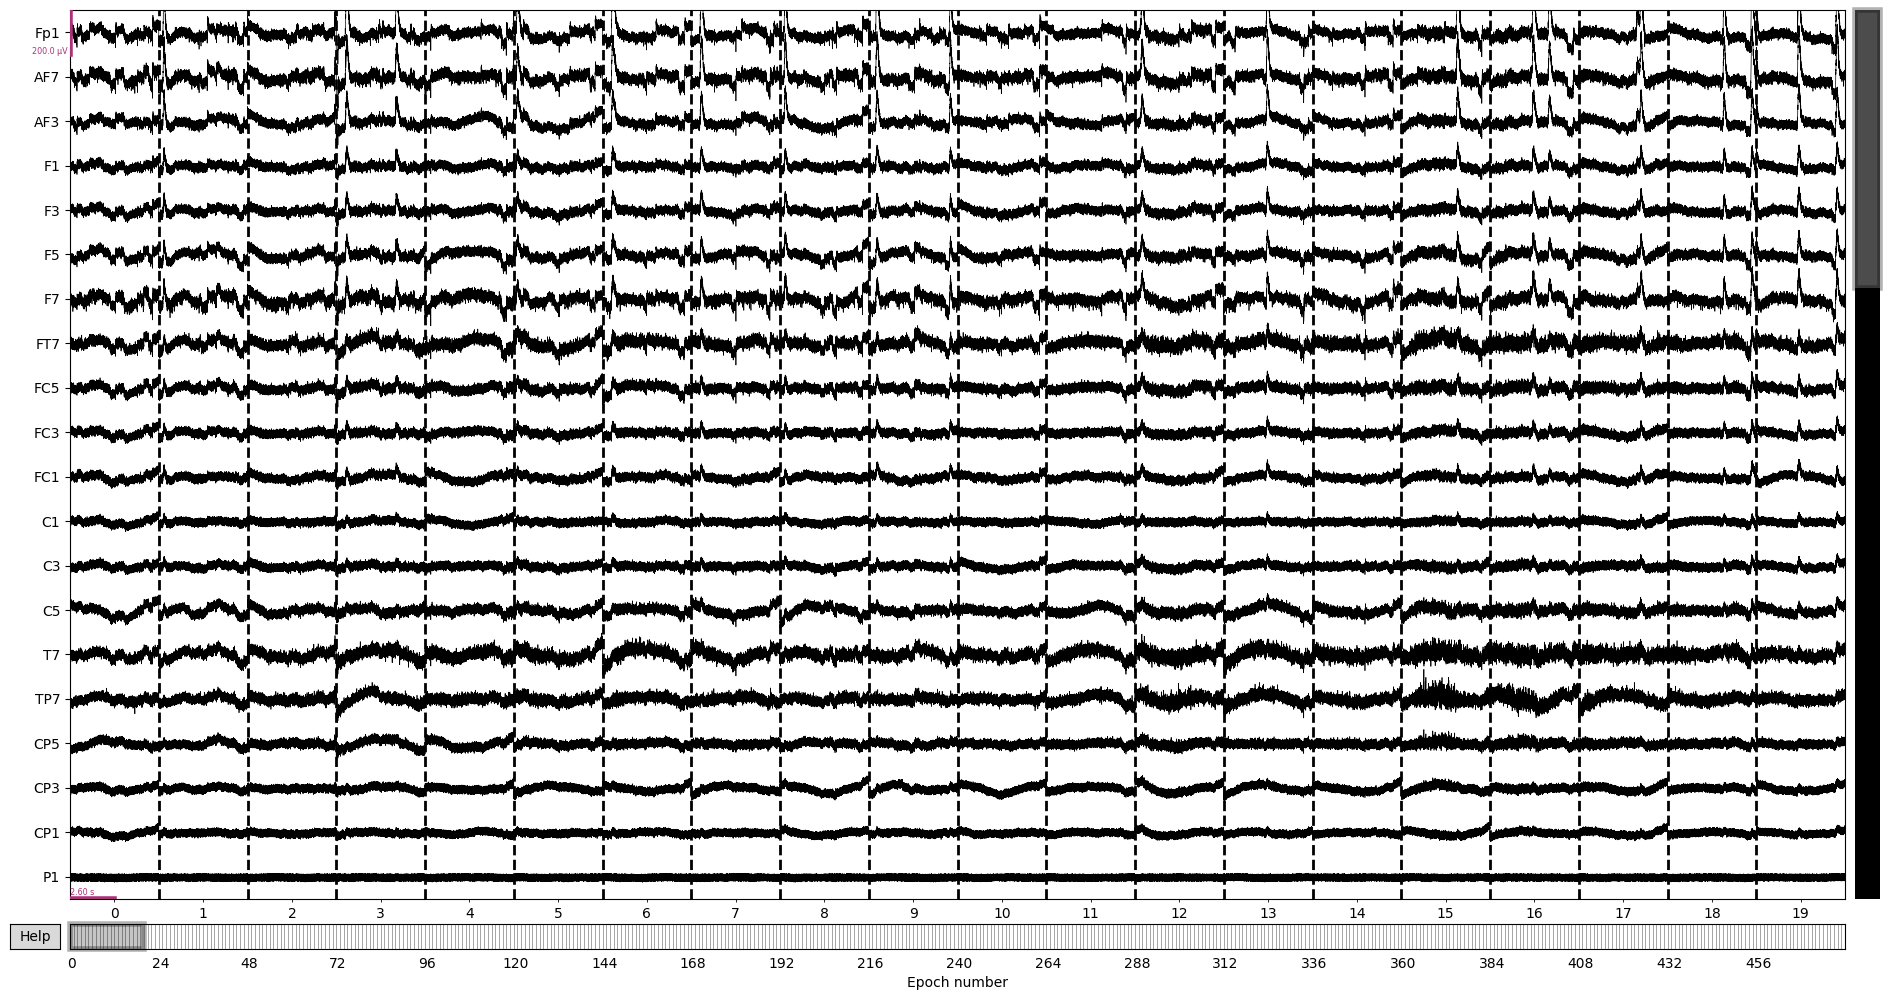

In [17]:
epochs_p1_detrend = sub1.epoch_players(raw_p1, detrend=1)
epochs_p1_no_detrend =  sub1.epoch_players(raw_p1, detrend=1)

epochs_p1_no_detrend.plot(scalings={"eeg": 100e-6}, n_epochs=20)

Using data from preloaded Raw for 480 events and 10651 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 20 events and 10651 original time points ...


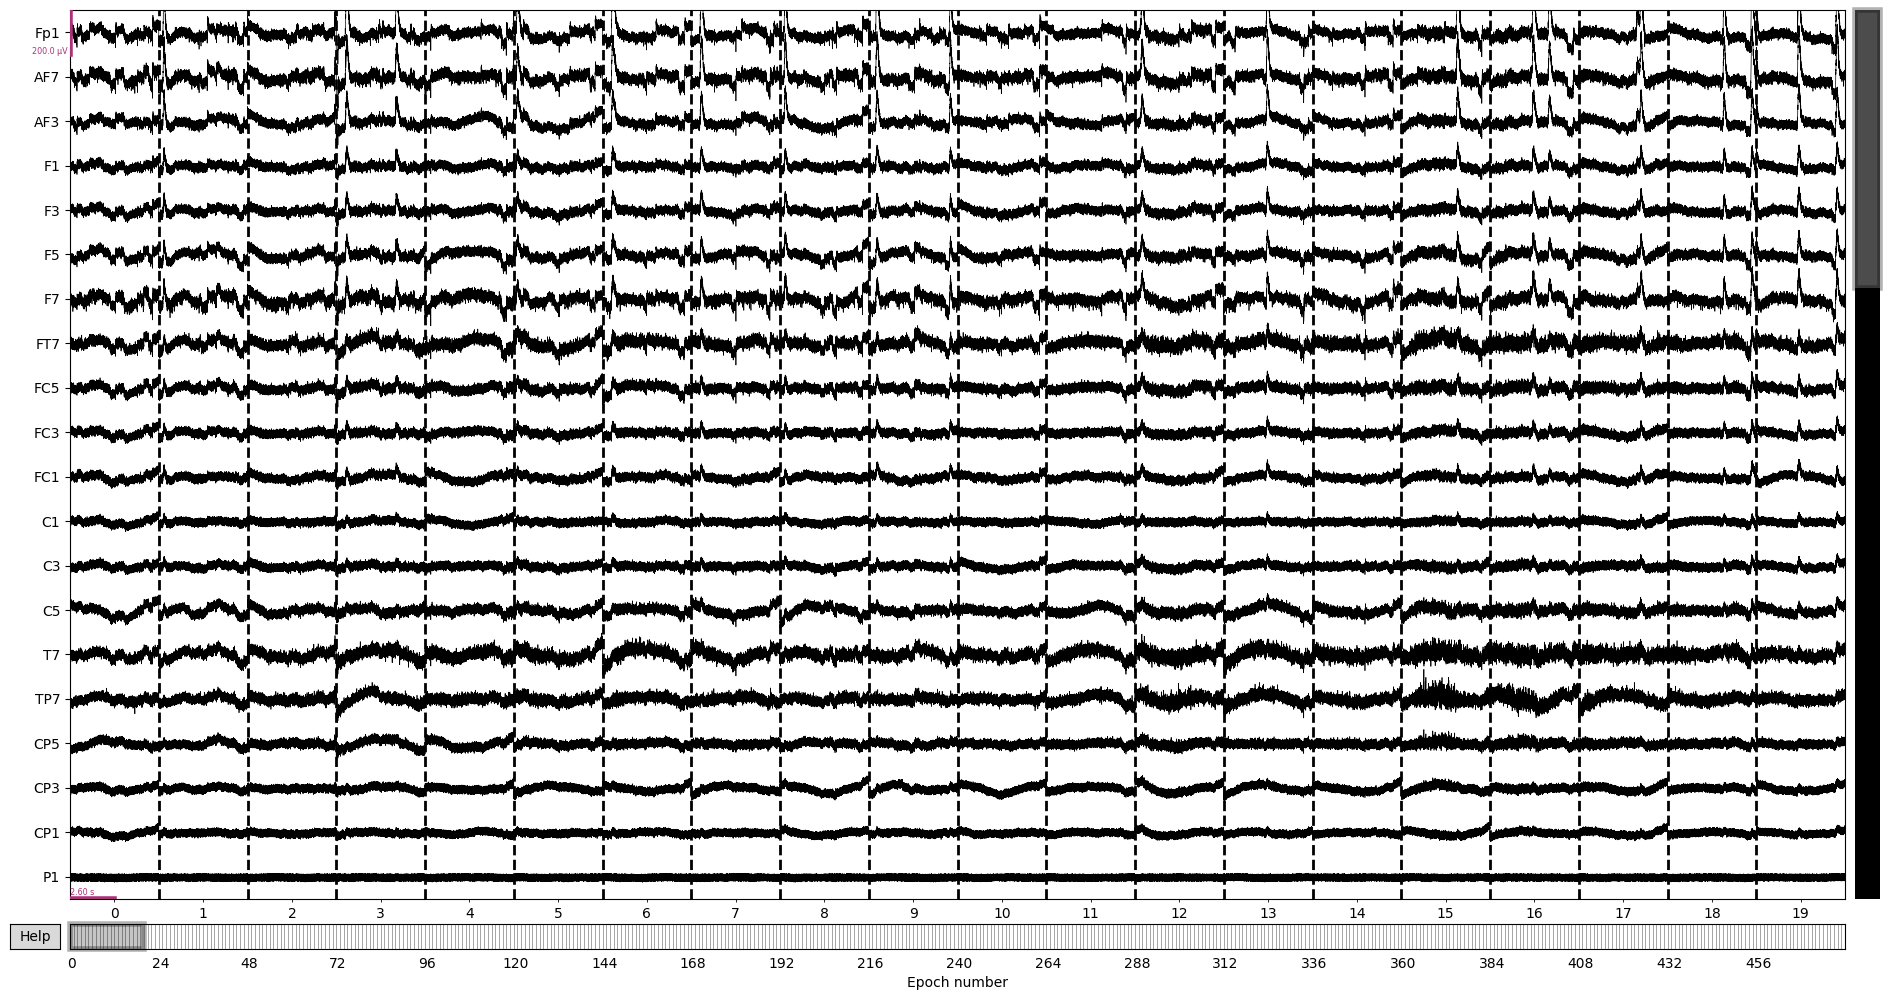

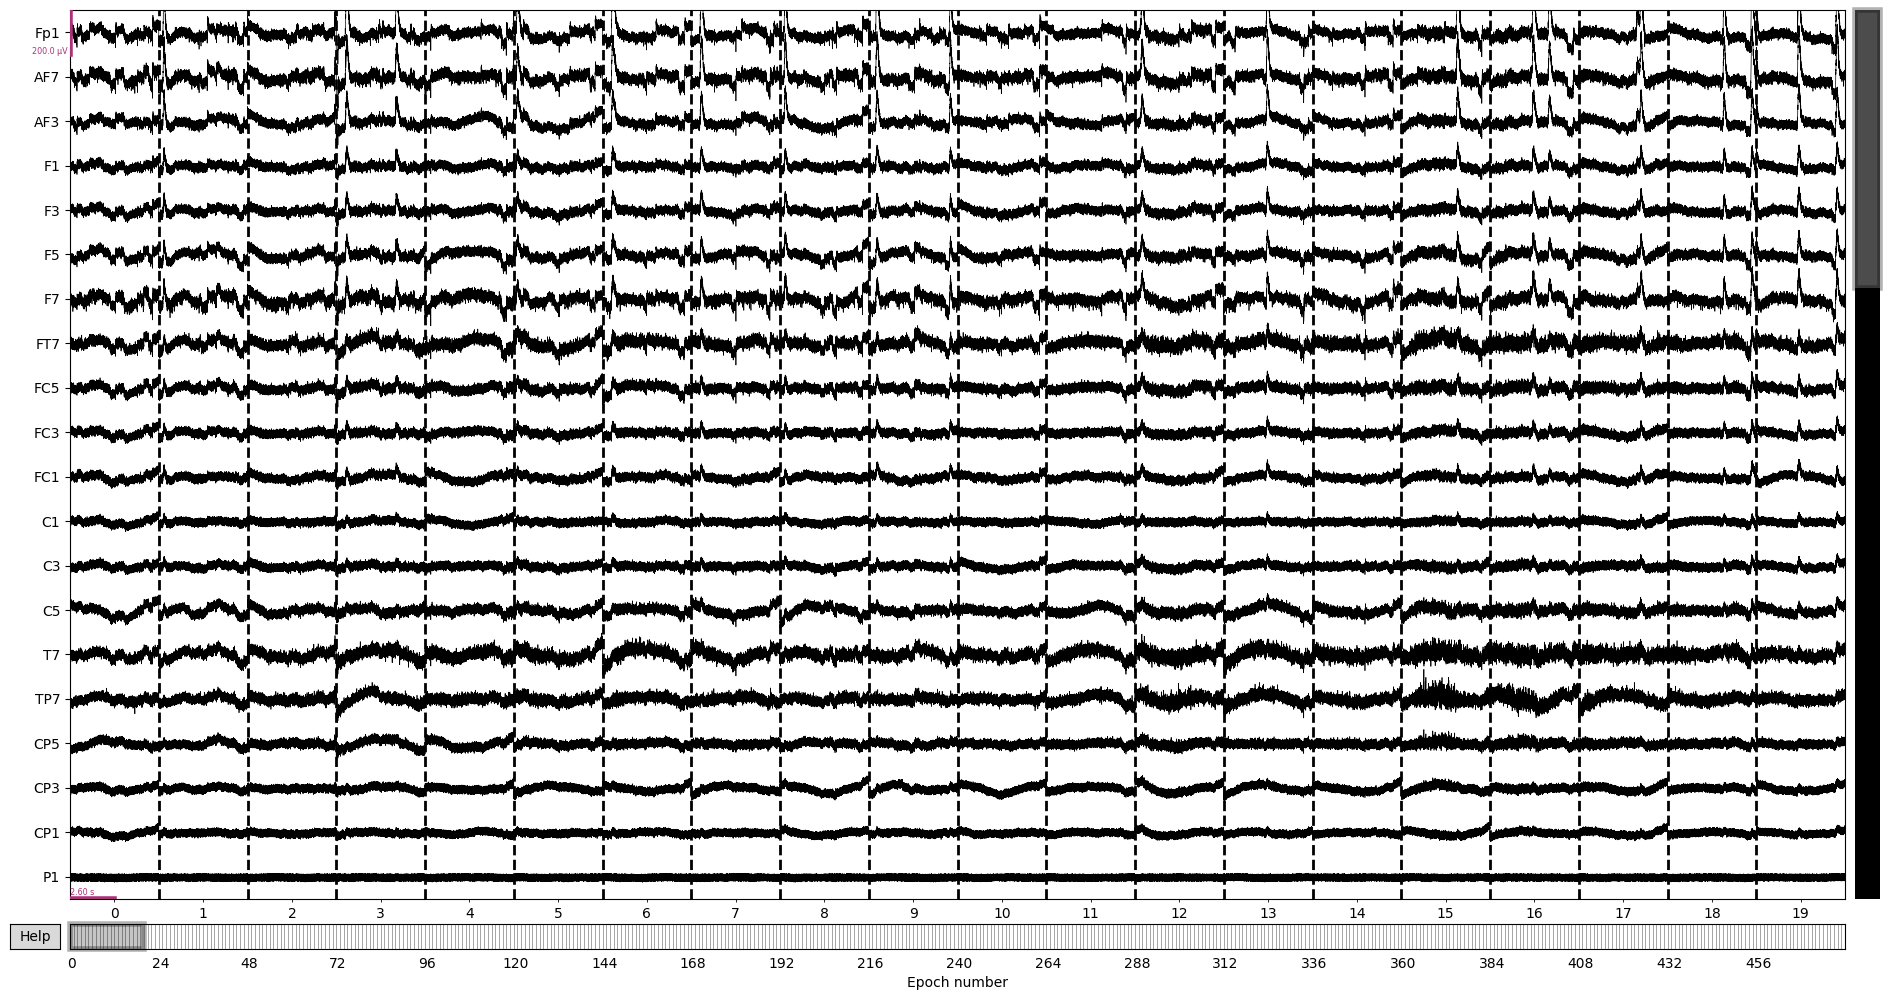

In [18]:
epochs_p1_detrend.plot(scalings={"eeg": 100e-6}, n_epochs=20)

The visual comparison shows no noticeable difference in waveform shape or amplitude. This suggests that linear detrending has little or no practical effect on this data, at least at the level of visual inspection. One likely reason is that the data was already high-pass filtered at 1 Hz before epoching, which removes much of the slow drift that detrending is designed to correct. In addition, baseline correction is applied later in the decoding pipeline, so any remaining slow offsets may already be compensated by subsequent preprocessing. Also, if the epochs contain only weak linear drifts anyways, detrending might naturally have very little visible impact. To confirm that the changes by applying linear detrending do not change the results much, we ran the whole pipeline once with it applied. The left image shows the pipeline with filtering and linear detrending (CoSMoMVPA-style), while the right image shows the results when only applying the filter. As suspected, there are no or very little visible differences between the two results.

<img src="\images\group_lda_cosmo_bandpass_detrended.png" width="400"> <img src="images/group_lda_cosmo_bandpass_1_35.png" width="400">

#### 4.1.4 Effect of dropping the channels identified as bad instead of interpolating them

In an additional analysis, we inspected the impact of the bad-channel handling via interpolation by omitting this step and instead completely removing all channels that had been identified as bad in the original study. Interestingly, this manipulation resulted in virtually identical decoding performance compared to the interpolation approach. One possible explanation is that the affected channels contributed little task-relevant information, either because they are dominated by noise or because their signal was redundant with neighboring electrodes. In such cases, interpolation does not introduce new information but rather reconstructs already available spatial patterns. As a result, whether these channels are interpolated or excluded seems to have a minimal impact on the classifier, which suggests that the decoding results are driven primarily by the more robust signals across the remaining set of channels.

<img src="images/group_lda_cosmo_dropped.png" width="400"> <img src="images/group_lda_cosmo.png" width="400">

### 4.2 Linear Decoding: Comparing Classifiers Beyond LDA

#### 4.2.1 Motivation:

The original paper uses a single classifier (regularised LDA with $\lambda = 0.01$) for all decoding analyses. While LDA is a standard and well-motivated choice, a natural question is whether the results depend on this particular classifier. If the decoded neural information is genuinely present in the EEG signal, it should be recoverable by different linear classifiers, each of which makes different assumptions about the data and uses different optimisation objectives. Conversely, if the results were an artefact of LDA's specific regularisation or its sensitivity to particular covariance structures, alternative classifiers might yield qualitatively different temporal profiles.

#### 4.2.2 Implementation

To test this, we ran the identical decoding pipeline (same pseudo-trials, same cross-validation folds, same time bins) with four linear classifiers:

1. **LDA (CoSMoMVPA-style):** Our custom reimplementation matching the original paper's regularised LDA with $\lambda = 0.01$ additive regularisation. This serves as the reproduction baseline.

2. **Shrinkage LDA (Ledoit-Wolf):** Scikit-learn's `LinearDiscriminantAnalysis` with `shrinkage='auto'`, which analytically computes the optimal shrinkage intensity using the Ledoit-Wolf estimator rather than relying on a fixed $\lambda$. The key difference from the CoSMoMVPA variant is that the regularisation strength adapts to each training set: when the sample covariance is well-conditioned, shrinkage is minimal; when it is poorly conditioned, shrinkage increases automatically. This makes the classifier less sensitive to the arbitrary choice of $\lambda = 0.01$. Additionally, as discussed in the reproduction section, scikit-learn uses a convex combination formula ($\Sigma_\text{reg} = (1-\alpha)\Sigma + \alpha \cdot \mu I$) rather than the additive one, meaning it slightly down-weights the off-diagonal covariance structure as shrinkage increases.

In [ ]:
def classify_shrinkage_lda(train_data, train_labels, test_data):
    clf = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
    clf.fit(train_data, train_labels)
    return clf.predict(test_data)

3. **Linear SVM:** A linear support vector machine (`LinearSVC` with $C = 1.0$) that finds the maximum-margin separating hyperplane between classes. Unlike LDA, which models the class-conditional distributions and finds the Bayes-optimal boundary under Gaussian assumptions, SVM directly optimises the decision boundary without modelling the full distributions. This makes SVM potentially more robust when the Gaussian assumption is violated (e.g., when EEG voltage distributions have heavier tails than a Gaussian). Because SVM's hinge loss is sensitive to feature scale, we z-score the features using the training set mean and standard deviation before fitting, applying the same transformation to the test set.

In [ ]:
def classify_svm(train_data: np.ndarray, train_labels: np.ndarray, test_data: np.ndarray) -> np.ndarray:
    """Linear SVM with z-scored features."""
    train_scaled, test_scaled = zscore(train_data, test_data)
    clf = LinearSVC(C=1.0, max_iter=10000, dual="auto")
    clf.fit(train_scaled, train_labels)
    return clf.predict(test_scaled)

4. **Logistic Regression (L2):** Multinomial logistic regression (`LogisticRegression` with $C = 1.0$, L-BFGS solver) that minimises the cross-entropy loss with L2 regularisation. Like SVM, it directly optimises a discriminative objective rather than modelling class distributions. Logistic regression offers an interesting middle ground: like LDA, it produces probabilistic class predictions, but like SVM, it does not assume Gaussian class-conditional distributions. Feature standardisation is essential here: without z-scoring, channels with large voltage ranges dominate the gradient, effectively causing the optimiser to ignore smaller channels and predict the majority class uniformly, producing chance-level accuracy.

In [ ]:
def classify_logreg(train_data: np.ndarray, train_labels: np.ndarray, test_data: np.ndarray) -> np.ndarray:
    """L2-regularised multinomial logistic regression with z-scored features."""
    train_scaled, test_scaled = zscore(train_data, test_data)
    clf = LogisticRegression(C=1.0, max_iter=10000, solver="lbfgs")
    clf.fit(train_scaled, train_labels)
    return clf.predict(test_scaled)

A note on feature standardisation: LDA (both variants) is inherently invariant to affine feature transformations, because the covariance matrix captures the relative scaling of features. SVM and logistic regression are not, so their loss functions treat all features equally in the raw input space. Channels with larger voltage ranges would dominate the decision boundary unless the features are standardised first. The z-scoring is computed from the training set and applied to both training and test data within each cross-validation fold, preventing any information leakage.

#### 4.2.3 Results

The four figures show the temporal decoding accuracy for each classifier across the four decode targets (own response, opponent's response, own previous response, opponent's previous response). The dashed line at 33.3% marks theoretical chance for 3-class classification, and the shaded bands show the 95% confidence interval across participants.

**Own response (panel a).** All four classifiers recover the same temporal profile: accuracy rises modestly above chance during the Decision phase (~34–35%), peaks sharply in the early Response phase (~38%), drops back to just above chance by late Response, and then peaks less sharply during Feedback (~36%). The peak during the Response phase corresponds to the moment participants execute their button press, when the neural representation of the chosen action is strongest. The fact that accuracy is already above chance during the Decision phase confirms the original paper's finding that participants begin forming their decision during this preparatory period. All four classifiers agree on this profile, with confidence intervals overlapping at every time bin.

**Opponent's response (panel b).** All classifiers show accuracy at or below chance during the Decision and Response phases, rising sharply only during Feedback when the opponent's choice is visually displayed. The Feedback-phase peak (~38–39%) is visually driven, and all four classifiers detect it equally well. The absence of above-chance decoding during Decision and Response confirms that participants cannot reliably predict their opponent's next move, consistent with the behavioural unpredictability discussed in the paper.

**Own previous response (panel c).** Decoding accuracy for the player's own choice on the preceding trial is modestly above chance during the Decision phase (~34–35%) and the Response phase (~35%), hovering close to the chance line during Feedback. This subtle effect suggests that a trace of the previous action persists into the current trial's decision period. All four classifiers capture this pattern with similar magnitude and timing, though the effect is small relative to the confidence intervals.

**Opponent's previous response (panel d).** All classifiers show an early Decision-phase peak (~36–37% at the first time bin), after which accuracy gradually returns toward chance. This early peak suggests that participants encode what their opponent played on the previous trial at the very start of the new decision period, potentially reflecting a strategy of incorporating the opponent's recent behaviour. Again, the temporal profile is consistent across all four classifiers.

<img src="images/group_lda_cosmo.png" width="400"> <img src="images/group_shrinkage_lda.png" width="400">

<img src="images/group_linear_svm.png" width="400"> <img src="images/group_logistic_reg.png" width="400">

#### 4.2.4 Interpretation

The most striking result of this comparison is the convergence: all four classifiers produce virtually indistinguishable temporal profiles for every decode target. This convergence is informative for several reasons.

First, it demonstrates that the original paper's findings are robust to classifier choice. The decoded neural information is not an artefact of LDA's specific regularisation formula or its Gaussian distributional assumptions. Whether we use a generative model (LDA), a discriminative margin-based model (SVM), or a discriminative probabilistic model (logistic regression), the same temporal structure emerges. This strengthens confidence that the decoding reflects genuine neural representations rather than classifier-specific biases.

Second, the convergence tells us something about the nature of the neural signal. When different linear classifiers with different loss functions (quadratic, hinge, cross-entropy) all achieve the same accuracy, it suggests that the discriminative information resides primarily in the class means (the spatial distribution of average voltages across channels for Rock vs Paper vs Scissors) rather than in the covariance structure. LDA explicitly models the covariance, while SVM and logistic regression ignore it. So, the fact that they perform equally well implies that the covariance plays a minor role in separating the classes. In other words, the EEG patterns distinguishing the three responses differ mainly in where activity is stronger or weaker across the scalp, not in how activity co-varies between channels.

Third, the similar performance of the fixed-regularisation LDA ($\lambda = 0.01$) and the data-adaptive Shrinkage LDA (Ledoit-Wolf) suggests that the fixed regularisation chosen by the original authors was already near-optimal for this dataset. The Ledoit-Wolf estimator, which analytically minimises the expected squared error between the shrunk and true covariance, provides no measurable advantage. This reassures that the original results are not sensitive to the specific regularisation parameter, and a different (reasonable) choice of $\lambda$ would likely have produced similar findings.

Finally, the fact that z-scored SVM and logistic regression match the LDA results despite the additional preprocessing step (feature standardisation) suggests that there are no channels with extreme voltage ranges that disproportionately drive the LDA results. If a few high-variance channels had been dominating the LDA covariance estimate, the z-scored classifiers (which equalise channel contributions) would have shown different accuracy profiles. The consistency indicates that the neural information is distributed across channels of comparable variance, which aligns with the searchlight topographies reported in the paper showing spatially distributed encoding.

### 4.3 Non-Linear Decoding

#### 4.3.1 Motivation

The original study uses a linear decoding approach relying on LDA, which is interpretable, computationally efficient, and robust in high-dimensional settings. As demonstrated in both the original work and our reproduction (Section 3.2) and the classifier comparison (Section 4.2), linear classifiers are capable of extracting meaningful information from temporally resolved EEG signals, and the decoded information is consistent across different linear methods.

Despite these strengths, linear approaches impose a fundamental assumption: that the relationship between neural activity patterns and cognitive states can be captured by linear decision boundaries. EEG signals, however, arise from complex, non-linear neural dynamics, including non-linear interactions across brain regions, oscillatory coupling, and time-dependent processes. It is therefore plausible that linear models capture only a subset of the information encoded in the data, specifically the portion that manifests as differences in mean spatial patterns across conditions.

The use of non-linear models, such as convolutional neural networks (CNNs), offers a potential extension of this framework. Architectures like EEGNet (Lawhern et al., 2018) have been specifically designed for EEG data and have demonstrated success in various classification tasks. Rather than replacing the original linear analysis, our contribution aims to investigate whether introducing a non-linear model within the same decoding pipeline can capture additional structure in the data. So we aimed for a controlled comparison between linear and non linear decoding approuches under identical preprocessing and evaluation conditions


#### 4.3.2 Implementation Details

The input data for EEGNet was prepared identically to the linear decoding pipeline: the preprocessed `.fif` epoch files were transformed into a time-resolved representation by averaging signals within the same 250 ms temporal windows used throughout this report. Each trial was split into the three task phases (Decision, Response, and Feedback), baseline-corrected per phase, and averaged into 8 + 8 + 4 = 20 time bins. Behavioural labels were constructed to match the four decoding targets of the original study (own response, opponent's response, own previous response, opponent's previous response), and trials with missing or invalid responses were excluded.

Pseudo-trial averaging was applied using the same procedure as the linear pipeline (averaging 4 trials of the same class and fold, repeated 20 times). While this reduces the total number of available training samples, a potential concern for data-hungry neural networks, it was retained to ensure a fair comparison: any difference in performance between the linear and non-linear classifiers should reflect the model's capacity, not differences in input preprocessing.

##### EEGNet Architecture

To introduce non-linearity, we employed EEGNet, a lightweight convolutional neural network designed specifically for EEG data. The architecture consists of three stages:

1. Temporal convolutions: Two convolutional layers with small kernels (size 5, corresponding to approximately 100–200 ms at our temporal resolution) extract short-term temporal features. Each is followed by batch normalisation, an ELU activation, and dropout ($p = 0.3$).

2. Spatial convolution: A convolution with kernel size `(n_channels, 1)` integrates information across all EEG channels. This is analogous to learned spatial filters (similar in spirit to Common Spatial Patterns), but the filters are optimised end-to-end for the classification objective rather than being derived from the covariance structure.

3. Pooling and classification: Adaptive average pooling reduces the representation to a single vector per trial, which is passed through a fully connected layer to produce class logits.

In [ ]:
class EEGNet(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, (1, 5), padding=(0, 2)),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.Dropout(0.3),

            nn.Conv2d(32, 64, (1, 5), padding=(0, 2)),
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.Dropout(0.3),

            nn.Conv2d(64, 64, (n_channels, 1)),
            nn.BatchNorm2d(64),
            nn.ELU(),

            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(64, n_classes)
        )

Key design decisions and their rationale:

- Dropout regularisation ($p = 0.3$): EEG datasets are small relative to the number of parameters in even a lightweight CNN. Dropout is essential to prevent overfitting by randomly zeroing activations during training, forcing the network to learn redundant representations.
- Batch normalisation: Stabilises training by normalising layer activations, which is particularly important for EEG data where voltage distributions can vary substantially across participants and sessions.
- ELU activation: Chosen over ReLU because ELU produces non-zero gradients for negative inputs, which can help with the small training set sizes typical of EEG decoding.

##### Training Procedure

The model was trained using Adam optimisation ($\text{lr} = 10^{-3}$) with cross-entropy loss. Rather than using the same 10-fold cross-validation as the linear classifiers, a stratified 80/20 train-test split was used, especially due to computational reasons (training time takes more than 6 hours in a cross-validation setting). This methodological difference should be kept in mind when comparing results, though it does not explain the magnitude of the performance gap observed.

In [ ]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y)

Performance was evaluated using balanced accuracy, which accounts for any residual class imbalance by computing the average per-class recall.

#### 4.3.3 Results and Interpretation

The non-linear EEGNet model achieved performance that remained close to chance level (~33.3%) across all four decoding targets, with only small and inconsistent deviations above chance. This stands in clear contrast to the linear classifiers, which all reliably decoded own-response information during the Response and Feedback phases, and detected subtler effects for previous-trial information during the Decision phase.


##### Training Dynamics

The training curves reveal a characteristic overfitting pattern: training accuracy increases steadily across epochs, while test accuracy remains unstable and close to chance. The persistent gap between training and test performance indicates that the network is memorising the training data rather than learning generalisable features. This is a well-known failure mode for deep learning models applied to small datasets.

##### Why Does EEGNet Fail Where Linear Classifiers Succeed?

First, the limited sample size is a major constraint. After pseudo-trial averaging, only a relatively small number of samples remain per participant. While this is sufficient for linear models, it is not enough to reliably train a neural network with many parameters. As a result, EEGNet is prone to overfitting and fails to generalise to unseen data.

Second, the structure of the signal appears to be largely linear. The comparison of multiple linear classifiers showed highly similar decoding performance despite different optimisation principles. This suggests that the discriminative information is primarily captured by differences in mean spatial activation patterns, leaving limited additional structure for a non-linear model to exploit. Consistent with this, EEGNet achieves higher training accuracy but remains at chance level on the test set, indicating that it is fitting noise rather than meaningful patterns.

Finally, the temporal representation limits the effectiveness of convolutional layers. The model operates on sliding windows of only three 250 ms time bins (750 ms total), providing a very restricted temporal context. In addition, each time bin is already averaged over many raw EEG samples, meaning that fine-grained temporal dynamics are largely removed. As a result, the temporal convolutions have little meaningful structure to learn from. The results obtained without cross-validation are shown below:

<img src="images/nonlinear.JPG" width="400"> 


##### Attempted Remedies

We explored several modifications to address these issues:

- **Stratified cross-validation:** To align the evaluation with the linear decoding we introduced a stratified cross-validation. This substantially increased computational cost (up to several hours) without leading to meaningful improvements in decoding performance. However, it resulted in smoother decoding accuracy curves, reflecting reduced variance across folds rather than improved generalisation.
- **Reduced pseudo-trial averaging:** Decreasing the number of trials per pseudo-trial increased noise in the data and led to a degradation in decoding performance
- **Varying temporal window sizes:** Modifying the temporal window length did not yield consistent improvements, suggesting that the temporal resolution of the input representation was not the primary limiting factor.

The results obtained with cross-validation are shown below:

<img src="images/nonlinear_cv.JPG" width="400"> 

##### Interpretation

Taken together, these findings suggest that the limitations are not due to specific modelling choices, but rather reflect constraints of the data itself, including low signal-to-noise ratio and limited sample size at the trial level. Under these conditions, linear models are better suited due to their stronger inductive bias and lower complexity.

## 5. Conclusions

This report reanalysed the EEG hyperscanning dataset from Moerel et al. (2025), reproducing the original decoding pipeline in Python and extending it with additional classifiers and a non-linear model.

**Preprocessing reproduction and contributions.** We reimplemented the original FieldTrip-based preprocessing in MNE-Python, including a custom weighted-distance interpolation to match FieldTrip's `ft_channelrepair` behaviour, sample-level epoch boundary alignment, and resampling from 2048 Hz to 256 Hz. During this process, we identified a discrepancy in the original paper: the authors state that re-referencing to the common average was the first preprocessing step, but their MATLAB script shows it was applied after epoching and interpolation — a meaningful distinction, since re-referencing before interpolation would spread bad-channel noise across all channels. As our own contribution, we explored whether additional preprocessing steps could improve decoding. Applying a 1–35 Hz band-pass filter to the raw data before epoching produced slight improvements in some conditions (particularly during the Feedback phase for opponent decoding) but did not fundamentally alter the temporal decoding profiles. Comparing interpolation of bad channels against simply dropping them revealed virtually identical performance, suggesting that the interpolated channels contribute little unique information to the classifier. These findings are consistent with recent work showing that preprocessing choices can affect decoding in non-obvious ways, and that the relationship between signal cleaning and classification performance is not straightforward.

**Decoding reproduction.** The CoSMoMVPA-based decoding pipeline was reimplemented using NumPy, including three custom components where no Python equivalent exists: the regularised LDA classifier (matching CoSMoMVPA's additive regularisation formula, which differs from scikit-learn's convex combination), the balanced pseudo-trial sampling scheme (`cosmo_sample_unique`, which ensures each trial is used approximately equally across repeats), and the fold assignment function (`cosmo_chunkize`, which balances classes across folds). The phase-wise baseline correction and 250 ms time-binning were implemented manually to match the MATLAB code's strict inequality boundaries and time-shifting logic. The channel searchlight was reproduced using Euclidean nearest-neighbour selection from the BioSemi montage positions.

**Linear classifier comparison.** Extending the original LDA-based analysis with Shrinkage LDA (Ledoit-Wolf), Linear SVM, and L2-regularised Logistic Regression revealed a striking convergence: all four classifiers produced virtually identical temporal decoding profiles across all decode targets. This convergence has two implications. First, it demonstrates that the original paper's findings are robust to classifier choice and not dependent on the specific properties of CoSMoMVPA's LDA. Second, it suggests that the discriminative information in the EEG signal is primarily linear in nature, residing in the mean spatial patterns (class centroids) rather than in the covariance structure or higher-order statistics.

**Non-linear decoding.** The EEGNet-based non-linear decoding produced chance-level performance across all decode targets, consistent with the linear-separability interpretation above. However, several preprocessing and protocol differences between the linear and non-linear pipelines (absence of baseline correction, simpler pseudo-trial construction, sliding window rather than per-bin decoding) mean this result should be interpreted cautiously. The negative result is nevertheless informative: it suggests that, for this dataset and temporal resolution, a more complex model does not recover additional information.

**Broader lessons.** This project illustrates several practical lessons for EEG analysis. Reproducing published results requires careful attention to implementation details, seemingly minor differences in regularisation formulas, sampling schemes, or baseline correction can affect the results. The modularity of the codebase (separating data loading, preprocessing, classification, and plotting into distinct modules) proved essential for managing this complexity. Finally, the professor's emphasis on documenting motivation and reasoning was well-placed: many of the most important decisions in this project were not about which analysis to run, but about understanding why a particular choice was made and what its consequences would be.

## References

Delorme, A. (2023). EEG is better left alone. *Scientific Reports*, 13, 2372. https://doi.org/10.1038/s41598-023-27528-0

Grootswagers, T., Wardle, S. G., & Carlson, T. A. (2017). Decoding dynamic brain patterns from evoked responses: A tutorial on multivariate pattern analysis applied to time series neuroimaging data. *Journal of Cognitive Neuroscience*, 29(4), 677–697. https://doi.org/10.1162/jocn_a_01068

Guggenmos, M., Sterzer, P., & Cichy, R. M. (2018). Multivariate pattern analysis for MEG: A comparison of dissimilarity measures. *NeuroImage*, 173, 434–447. https://doi.org/10.1016/j.neuroimage.2018.02.044

Klug, M., & Gramann, K. (2025). How EEG preprocessing shapes decoding performance. *Communications Biology*, 8, 252. https://doi.org/10.1038/s42003-025-08464-3

Lawhern, V. J., Solon, A. J., Waytowich, N. R., Gordon, S. M., Hung, C. P., & Lance, B. J. (2018). EEGNet: A compact convolutional neural network for EEG-based brain–computer interfaces. *Journal of Neural Engineering*, 15(5), 056013. https://doi.org/10.1088/1741-2552/aace8c

Lotte, F., Bougrain, L., Cichocki, A., Clerc, M., Congedo, M., Rakotomamonjy, A., & Yger, F. (2018). A review of classification algorithms for EEG-based brain–computer interfaces: A 10 year update. *Journal of Neural Engineering*, 15(3), 031005. https://doi.org/10.1088/1741-2552/aab2f2

Moerel, D., Grootswagers, T., Chin, J. L. L., Ciardo, F., Nijhuis, P., Quek, G. L., Smit, S., & Varlet, M. (2025). Neural decoding of competitive decision-making in Rock–Paper–Scissors. *Social Cognitive and Affective Neuroscience*, 20(1), nsaf101. https://doi.org/10.1093/scan/nsaf101

Oostenveld, R., Fries, P., Maris, E., & Schoffelen, J.-M. (2011). FieldTrip: Open source software for advanced analysis of MEG, EEG, and invasive electrophysiological data. *Computational Intelligence and Neuroscience*, 2011, 1–9. https://doi.org/10.1155/2011/156869

Oosterhof, N. N., Connolly, A. C., & Haxby, J. V. (2016). CoSMoMVPA: Multi-modal multivariate pattern analysis of neuroimaging data in Matlab/GNU Octave. *Frontiers in Neuroinformatics*, 10, 27. https://doi.org/10.3389/fninf.2016.00027

van Driel, J., Olivers, C. N. L., & Fahrenfort, J. J. (2021). High-pass filtering artifacts in multivariate classification of neural time series data. *Journal of Neuroscience Methods*, 352, 109080. https://doi.org/10.1016/j.jneumeth.2021.109080